In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [3]:
df=pd.read_csv(r"D:\Python and projects\summer\House Price Pred\house_prices_dirty_dataset.csv")


In [4]:
df.shape

(9730, 40)

In [29]:
pd.set_option('display.max_columns', None)
df.head()

,Property_ID,MLS_Number,Listing_Date,Sale_Date,Street_Address,City,State,Zip_Code,Country,Latitude,Longitude,Property_Type,Bedrooms,Bathrooms,Lot_Size_SqFt,Living_Area_Reported,Year_Built,Garage_Spaces,Has_Pool,Has_Garden,Heating_Type,Cooling_Type,School_Rating,Crime_Rate_Index,Neighborhood_Quality_Score,Distance_To_City_Center_Reported,HOA_Fee_Monthly,Property_Tax_Annual,Days_On_Market,List_Price,Sale_Price,Price_Per_SqFt,Is_Foreclosure,Currency,Agent_Name,Agent_Phone,Agent_Email,Buyer_Feedback
0,PROP-103914,MLS-103914,2023-09-25,2025-06-15,43979 Sarah Garden,SEATTLE,Washington,65866.0,USA,41.497476,-107.137238,HOUSE,1,1.0,24440.9,144.176166,2002.0,2.0,0,1,Gas,Window Unit,6.5,9.77,73.6,19.440000,4.73,5323.18,41,274163.50,400499.371311,197.605121,1,USD,Austin Gonzales,9.932628e+09,austin.gonzales8@realty.com,"beautiful backyard, perfect for entertaining g..."
1,PROP-107192,MLS-107192,2024-12-26,2025-09-07,479 Richard Trail Apt. 514,MIAMI,Florida,81824.0,USA,37.096615,-103.096414,TOWNHOUSE,2,1.4,6985.1,171.600000,2013.0,2.0,0,1,Gas,Window Unit,6.8,1.28,68.5,3.090000,227.44,2787.67,13,324101.48,312852.880000,169.380000,0,USD,Kimberly Kline,5.536209e+09,kimberly.kline68@yahoo.com,amazing view of the mountains from the master ...
2,PROP-108438,MLS-108438,2024-08-15,2025-06-15,6154 Greene Fords Apt. 039,SACRAMENTO,California,80513.0,USA,41.189485,-98.803355,HOUSE,5,4.8,3697.6,62.551590,1991.0,2.0,0,0,Gas,Window Unit,6.2,3.39,65.6,5.300000,41.60,1424.95,0,98797.61,98767.290000,146.690000,0,USD,Pamela Davis,6.025323e+09,pamela.davis_at_yahoo.com,closing process took way longer than promised.
3,PROP-105480,MLS-105480,2025-08-21,2026-05-12,8312 Renee Junctions,SACRAMENTO,California,28454.0,USA,48.544489,-67.636640,CONDOMINIUM,2,1.0,2436.3,86.501983,1952.0,0.0,0,1,Gas,Window Unit,8.4,8.19,81.5,40.828956,169.99,1336.76,1,162391.10,163367.070000,175.460000,0,USD,Lauren Camacho,4.286688e+09,lauren.camacho37@gmail.com,"beautiful backyard, perfect for entertaining g..."
4,PROP-102468,MLS-102468,2025-05-09,2025-12-13,448 Kim Coves,CHICAGO,Illinois,90058.0,USA,27.647554,-108.595580,TOWNHOUSE,5,4.6,7285.7,225.652097,1986.0,2.0,1,1,Gas,Window Unit,10.0,4.82,84.8,9.050000,111.16,5077.33,9,489647.12,479931.120000,197.590000,0,USD,Alexis Alexander,6.025323e+09,alexis.alexander10@realty.com,traffic noise was worse than expected.


In [7]:
df.isna().sum().sort_values(ascending=False)

Year_Renovated                      7573
Cooling_Type                        6258
Buyer_Feedback                      4301
Sale_Date                           2964
Price_Per_SqFt                      2924
Sale_Price                          2919
Listing_Description                 1473
Heating_Type                         812
School_Rating                        780
Latitude                             473
Longitude                            463
Neighborhood_Quality_Score           292
Bathrooms                            289
Garage_Spaces                        196
Crime_Rate_Index                     191
Property_Tax_Annual                  166
List_Price                           143
HOA_Fee_Monthly                      125
Agent_Name                            97
Zip_Code                              86
Listing_Date                          34
Year_Built                            24
MLS_Number                             0
Property_ID                            0
State           

<Axes: title={'center': 'Missing Values'}, xlabel='Missing Persentage', ylabel='Columns'>

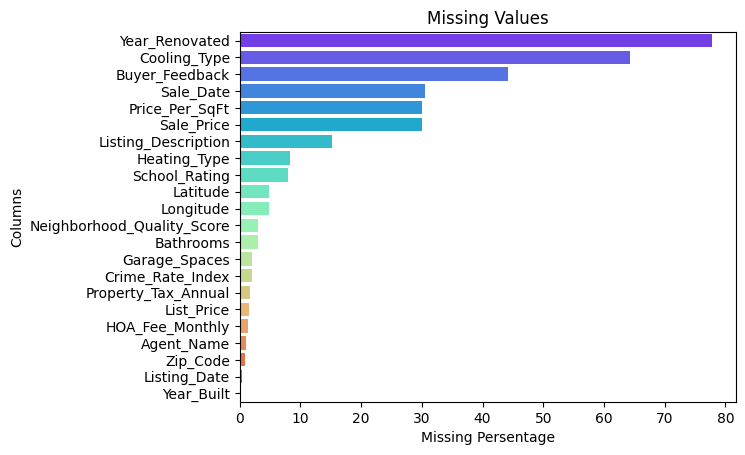

In [9]:
data=round((df.isna().sum().sort_values(ascending=False)*100)/len(df),2)
missing_value_percent=data[data>0]
plt.xlabel(xlabel="Missing Persentage")
plt.ylabel(ylabel="Columns")
plt.title("Missing Values")
sns.barplot(y=missing_value_percent.index,x=missing_value_percent.values,palette='rainbow')

In [15]:
df.duplicated().sum()

np.int64(0)

In [13]:
copy_df=df.copy()

In [14]:
df.drop_duplicates(inplace=True)

In [16]:
df.head()

,Property_ID,MLS_Number,Listing_Date,Sale_Date,Street_Address,City,State,Zip_Code,Country,Latitude,Longitude,Property_Type,Bedrooms,Bathrooms,Lot_Size_SqFt,Living_Area_Reported,Year_Built,Year_Renovated,Garage_Spaces,Has_Pool,Has_Garden,Heating_Type,Cooling_Type,School_Rating,Crime_Rate_Index,Neighborhood_Quality_Score,Distance_To_City_Center_Reported,HOA_Fee_Monthly,Property_Tax_Annual,Days_On_Market,List_Price,Sale_Price,Price_Per_SqFt,Is_Foreclosure,Currency,Agent_Name,Agent_Phone,Agent_Email,Listing_Description,Buyer_Feedback
0,PROP-103914,MLS-103914,09/25/2023,NaN,43979 Sarah Garden,Seattle,WA,65866,USA,41.497476,-107.137238,House,1,1.0,24440.9,1551.9 sqft,2002.0,2032.0,2.0,False,yes,Gas,NaN,6.5,9.77,73.6,19.44 km,4.73,"5,323.18",-41,"$274,163.50",NaN,NaN,Yes,USD,Austin Gonzales,(993) 262-8455,austin.gonzales8@realty.com,"Cozy Hous3 with gr3at pot3ntial, locat3d n3ar ...","Beautiful backyard, perfect for entertaining g..."
1,PROP-107192,MLS-107192,26/12/2024,07/09/2025,479 Richard Trail Apt. 514,Miamii,Floridà,81824,USA,NaN,-103.096414,Townhouse,2,1.4,6985.1,171.6 sqm,2013.0,NaN,2.0,No,true,Gas,Window Unit,6.8,1.28,68.5,3.09 km,$227.44,"$2,787.67",13,"$324,101.48",312852.88,169.38,False,USD,Kimberly Kline,(553) 620-8879,kimberly.kline68@yahoo.com,Spacious Townhouse featuring 2 bedrooms and 1....,Amazing view of the mountains from the master ...
2,PROP-108438,MLS-108438,"August 15, 2024",NaN,6154 Greene Fords Apt. 039,Sacramento,CA,80513,Usa,41.189485,-98.803355,House,5,4.8,3697.6,673.3 sqft,1991.0,2006.0,2.0,false,No,NaN,NaN,6.2,3.39,65.6,5.3 km,41.60,"$1,424.95",0,98797.61,98767.29,146.69,NO,USD,Pamela Davis,CALL-ME-4292,pamela.davis_at_yahoo.com,"Cozy House with great potential, located ne...",Closing process took way longer than promised.
3,PROP-105480,MLS-105480,21/08/2025,12-May-2026,8312 Renee Junctions,Sa acra amento,California,28454,Usa,48.544489,-67.636640,Condo,2,1.0,2436.3,931.1 sqft,1952.0,NaN,0.0,false,true,Gas,NaN,8.4,8.19,81.5,25.37 mi,169.99,"$1,336.76",1,"$162,391.10",163367.07,175.46,N,USD,Lauren Camacho,428-668-8350,lauren.camacho37@gmail.com,Spaciious Condo featuring 2 bedrooms and 1.0 b...,"Beautiful backyard, perfect for entertaining g..."
4,PROP-102468,MLS-102468,2025-09-05,2025-12-13,448 Kim Coves,Chicago,Illinois,90058,United States,27.647554,-108.595580,Townhouse,5,4.6,7285.7,2428.9 sqft,1986.0,NaN,2.0,Y,Yes,Gas,NaN,10.0,4.82,84.8,9.05 km,111.16,"5,077.33",9,"$489,647.12",479931.12,197.59,N,USD,Alexis Alexander,888.950.abcd,alexis.alexander10@realty.com,Charming 5-bed Townhouse in the heart of Chica...,NaN


In [19]:
df.describe(include='all')


,Property_ID,MLS_Number,Listing_Date,Sale_Date,Street_Address,City,State,Zip_Code,Country,Latitude,Longitude,Property_Type,Bedrooms,Bathrooms,Lot_Size_SqFt,Living_Area_Reported,Year_Built,Year_Renovated,Garage_Spaces,Has_Pool,Has_Garden,Heating_Type,Cooling_Type,School_Rating,Crime_Rate_Index,Neighborhood_Quality_Score,Distance_To_City_Center_Reported,HOA_Fee_Monthly,Property_Tax_Annual,Days_On_Market,List_Price,Sale_Price,Price_Per_SqFt,Is_Foreclosure,Currency,Agent_Name,Agent_Phone,Agent_Email,Listing_Description,Buyer_Feedback
count,9590,9590,9558,6667,9590,9590,9590,9508,9590,9120.000000,9128.000000,9590,9590,9304.000000,9.590000e+03,9590,9566.000000,2128.000000,9400.000000,9590,9590,8790,3429,8819.00000,9399.000000,9303.000000,9590,9467,9428,9590.000000,9447,6.711000e+03,6706.000000,9590,9590,9494,9590,9590,8143,5346
unique,9590,9500,4757,3106,9500,397,229,8788,7,NaN,NaN,23,34,NaN,NaN,7861,NaN,NaN,NaN,14,14,7,4,NaN,NaN,NaN,3275,7196,9182,NaN,9221,NaN,NaN,14,1,9048,9456,9499,4673,13
top,PROP-103914,MLS-105385,-,Feb 30 2023,6136 Melissa Crescent Suite 969,Boston,North Carolina,00000-####,US,NaN,NaN,House,2,NaN,NaN,300.0 sqft,NaN,NaN,NaN,NO,yes,Gas,Window Unit,NaN,NaN,NaN,0.13 km,$0.00,Unknown,NaN,Unknown,NaN,NaN,N,USD,Michael Jones,CALL-ME-3792,mr..christopher.tapia94@realty.com,"Fixer-upper House priced to sell, needs TLC bu...",Traffic noise was worse than expected.
freq,1,2,43,22,2,376,429,43,1435,NaN,NaN,2119,1805,NaN,NaN,82,NaN,NaN,NaN,1153,768,3286,905,NaN,NaN,NaN,15,430,74,NaN,73,NaN,NaN,1356,9590,5,4,2,264,446
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,42.156271,-100.475682,NaN,NaN,2.702687,8.388177e+03,NaN,2037.091992,1999.743421,1.701809,NaN,NaN,NaN,NaN,6.44039,14.822725,68.320058,NaN,NaN,NaN,33.711679,NaN,4.004166e+05,197.659763,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,69.944870,67.354562,NaN,NaN,1.656986,2.628625e+04,NaN,1088.732103,22.997147,1.061527,NaN,NaN,NaN,NaN,1.92217,14.691129,11.807788,NaN,NaN,NaN,35.363647,NaN,8.258197e+05,50.138602,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,25.002313,-999.000000,NaN,NaN,1.000000,6.778000e+02,NaN,-1990.000000,1907.000000,0.000000,NaN,NaN,NaN,NaN,1.00000,0.000000,6.900000,NaN,NaN,NaN,-60.000000,NaN,-6.936140e+05,42.340000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,31.204129,-110.350245,NaN,NaN,1.100000,4.031700e+03,NaN,1969.000000,1984.750000,1.000000,NaN,NaN,NaN,NaN,5.10000,4.350000,61.000000,NaN,NaN,NaN,9.000000,NaN,2.437966e+05,162.882500,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,37.193107,-95.881106,NaN,NaN,2.300000,6.059600e+03,NaN,1985.000000,2000.000000,2.000000,NaN,NaN,NaN,NaN,6.50000,10.480000,69.100000,NaN,NaN,NaN,23.000000,NaN,3.417715e+05,197.130000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,43.173437,-81.694912,NaN,NaN,3.700000,9.022575e+03,NaN,1999.000000,2016.000000,2.000000,NaN,NaN,NaN,NaN,7.80000,20.235000,76.500000,NaN,NaN,NaN,48.000000,NaN,4.562196e+05,231.065000,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [22]:
df['Property_ID'].count()

np.int64(9590)

In [26]:
df['MLS_Number'].duplicated().sum()
df.drop_duplicates(subset=["MLS_Number"],inplace=True)

In [27]:
df['MLS_Number'].duplicated().sum()

np.int64(0)

In [34]:
df['Property_Type'].unique()

<ArrowStringArray>
[      'House',   'Townhouse',      ' House',       'Condo',      'Duplex',
  'Town house',       'house',       'condo',         'Apt',   'apartment',
         'Hse',   'Apartment',       'HOUSE',   'APARTMENT',   'TOWNHOUSE',
       'CONDO',   'townhouse',       'Villa',       'VILLA', 'Condominium',
       'villa',        'Apt.',  'Town-house']
Length: 23, dtype: str

In [38]:
from difflib import get_close_matches
reference_prop_type=["House","Townhouse","Condominium","Apartment","Villa","Duplex"]

reference_prop_type=[x.lower() for x in reference_prop_type]

def clean_prop_type(txt):
    if pd.isna(txt):
        return np.nan
    
    best_match = get_close_matches(txt.strip().lower(), reference_prop_type, n=1, cutoff=0.4)
    if not best_match:
        return np.nan
    return best_match[0].upper()


df['Property_Type']=df['Property_Type'].apply(clean_prop_type)


In [42]:
df['Property_Type'].unique()

<ArrowStringArray>
['HOUSE', 'TOWNHOUSE', 'CONDOMINIUM', 'DUPLEX', 'APARTMENT', 'VILLA']
Length: 6, dtype: str

In [43]:
df.head()

,Property_ID,MLS_Number,Listing_Date,Sale_Date,Street_Address,City,State,Zip_Code,Country,Latitude,Longitude,Property_Type,Bedrooms,Bathrooms,Lot_Size_SqFt,Living_Area_Reported,Year_Built,Year_Renovated,Garage_Spaces,Has_Pool,Has_Garden,Heating_Type,Cooling_Type,School_Rating,Crime_Rate_Index,Neighborhood_Quality_Score,Distance_To_City_Center_Reported,HOA_Fee_Monthly,Property_Tax_Annual,Days_On_Market,List_Price,Sale_Price,Price_Per_SqFt,Is_Foreclosure,Currency,Agent_Name,Agent_Phone,Agent_Email,Listing_Description,Buyer_Feedback
0,PROP-103914,MLS-103914,09/25/2023,NaN,43979 Sarah Garden,Seattle,WA,65866,USA,41.497476,-107.137238,HOUSE,1,1.0,24440.9,1551.9 sqft,2002.0,2032.0,2.0,False,yes,Gas,NaN,6.5,9.77,73.6,19.44 km,4.73,"5,323.18",-41,"$274,163.50",NaN,NaN,Yes,USD,Austin Gonzales,(993) 262-8455,austin.gonzales8@realty.com,"Cozy Hous3 with gr3at pot3ntial, locat3d n3ar ...","Beautiful backyard, perfect for entertaining g..."
1,PROP-107192,MLS-107192,26/12/2024,07/09/2025,479 Richard Trail Apt. 514,Miamii,Floridà,81824,USA,NaN,-103.096414,TOWNHOUSE,2,1.4,6985.1,171.6 sqm,2013.0,NaN,2.0,No,true,Gas,Window Unit,6.8,1.28,68.5,3.09 km,$227.44,"$2,787.67",13,"$324,101.48",312852.88,169.38,False,USD,Kimberly Kline,(553) 620-8879,kimberly.kline68@yahoo.com,Spacious Townhouse featuring 2 bedrooms and 1....,Amazing view of the mountains from the master ...
2,PROP-108438,MLS-108438,"August 15, 2024",NaN,6154 Greene Fords Apt. 039,Sacramento,CA,80513,Usa,41.189485,-98.803355,HOUSE,5,4.8,3697.6,673.3 sqft,1991.0,2006.0,2.0,false,No,NaN,NaN,6.2,3.39,65.6,5.3 km,41.60,"$1,424.95",0,98797.61,98767.29,146.69,NO,USD,Pamela Davis,CALL-ME-4292,pamela.davis_at_yahoo.com,"Cozy House with great potential, located ne...",Closing process took way longer than promised.
3,PROP-105480,MLS-105480,21/08/2025,12-May-2026,8312 Renee Junctions,Sa acra amento,California,28454,Usa,48.544489,-67.636640,CONDOMINIUM,2,1.0,2436.3,931.1 sqft,1952.0,NaN,0.0,false,true,Gas,NaN,8.4,8.19,81.5,25.37 mi,169.99,"$1,336.76",1,"$162,391.10",163367.07,175.46,N,USD,Lauren Camacho,428-668-8350,lauren.camacho37@gmail.com,Spaciious Condo featuring 2 bedrooms and 1.0 b...,"Beautiful backyard, perfect for entertaining g..."
4,PROP-102468,MLS-102468,2025-09-05,2025-12-13,448 Kim Coves,Chicago,Illinois,90058,United States,27.647554,-108.595580,TOWNHOUSE,5,4.6,7285.7,2428.9 sqft,1986.0,NaN,2.0,Y,Yes,Gas,NaN,10.0,4.82,84.8,9.05 km,111.16,"5,077.33",9,"$489,647.12",479931.12,197.59,N,USD,Alexis Alexander,888.950.abcd,alexis.alexander10@realty.com,Charming 5-bed Townhouse in the heart of Chica...,NaN


In [85]:
copy_df=df.copy()

In [ ]:
copy_df['Bedrooms'].unique()

<ArrowStringArray>
[     '1',      '2',      '5',      '4',      '3',     '-1',      '0',
 '1 beds', '2 beds',      '7',      '6', '7 beds',     '-2',      '8',
     '-6', '6 beds', '3 beds',     '-3', '5 beds', '4 beds',     '-4',
 '0 beds',      '9',     '-5',     '-7', '8 beds',     '-8', '9 beds']
Length: 28, dtype: str

In [ ]:


reference_rooms={
    "zero":'0',
    "one":'1',
    "two":'2',
    "three":'3',
    "four":'4',
    "five":'5',
    "six":'6',
    "seven":'7',
    "eight":'8',
    "nine":'9',
    "ten":'10'
}

def room_correction(txt):
    no=reference_rooms.get(txt)
    if no is None:
        return txt
    return txt.replace(txt,no)

df['Bedrooms']=df['Bedrooms'].apply(room_correction)



In [79]:
df['Bedrooms']=df['Bedrooms'].str.split().str[0]

In [83]:

df['Bedrooms']=df['Bedrooms'].astype(int).abs()
df['Bedrooms'].unique()

array([1, 2, 5, 4, 3, 0, 7, 6, 8, 9])

In [86]:
df.head()

,Property_ID,MLS_Number,Listing_Date,Sale_Date,Street_Address,City,State,Zip_Code,Country,Latitude,Longitude,Property_Type,Bedrooms,Bathrooms,Lot_Size_SqFt,Living_Area_Reported,Year_Built,Year_Renovated,Garage_Spaces,Has_Pool,Has_Garden,Heating_Type,Cooling_Type,School_Rating,Crime_Rate_Index,Neighborhood_Quality_Score,Distance_To_City_Center_Reported,HOA_Fee_Monthly,Property_Tax_Annual,Days_On_Market,List_Price,Sale_Price,Price_Per_SqFt,Is_Foreclosure,Currency,Agent_Name,Agent_Phone,Agent_Email,Listing_Description,Buyer_Feedback
0,PROP-103914,MLS-103914,09/25/2023,NaN,43979 Sarah Garden,Seattle,WA,65866,USA,41.497476,-107.137238,HOUSE,1,1.0,24440.9,1551.9 sqft,2002.0,2032.0,2.0,False,yes,Gas,NaN,6.5,9.77,73.6,19.44 km,4.73,"5,323.18",-41,"$274,163.50",NaN,NaN,Yes,USD,Austin Gonzales,(993) 262-8455,austin.gonzales8@realty.com,"Cozy Hous3 with gr3at pot3ntial, locat3d n3ar ...","Beautiful backyard, perfect for entertaining g..."
1,PROP-107192,MLS-107192,26/12/2024,07/09/2025,479 Richard Trail Apt. 514,Miamii,Floridà,81824,USA,NaN,-103.096414,TOWNHOUSE,2,1.4,6985.1,171.6 sqm,2013.0,NaN,2.0,No,true,Gas,Window Unit,6.8,1.28,68.5,3.09 km,$227.44,"$2,787.67",13,"$324,101.48",312852.88,169.38,False,USD,Kimberly Kline,(553) 620-8879,kimberly.kline68@yahoo.com,Spacious Townhouse featuring 2 bedrooms and 1....,Amazing view of the mountains from the master ...
2,PROP-108438,MLS-108438,"August 15, 2024",NaN,6154 Greene Fords Apt. 039,Sacramento,CA,80513,Usa,41.189485,-98.803355,HOUSE,5,4.8,3697.6,673.3 sqft,1991.0,2006.0,2.0,false,No,NaN,NaN,6.2,3.39,65.6,5.3 km,41.60,"$1,424.95",0,98797.61,98767.29,146.69,NO,USD,Pamela Davis,CALL-ME-4292,pamela.davis_at_yahoo.com,"Cozy House with great potential, located ne...",Closing process took way longer than promised.
3,PROP-105480,MLS-105480,21/08/2025,12-May-2026,8312 Renee Junctions,Sa acra amento,California,28454,Usa,48.544489,-67.636640,CONDOMINIUM,2,1.0,2436.3,931.1 sqft,1952.0,NaN,0.0,false,true,Gas,NaN,8.4,8.19,81.5,25.37 mi,169.99,"$1,336.76",1,"$162,391.10",163367.07,175.46,N,USD,Lauren Camacho,428-668-8350,lauren.camacho37@gmail.com,Spaciious Condo featuring 2 bedrooms and 1.0 b...,"Beautiful backyard, perfect for entertaining g..."
4,PROP-102468,MLS-102468,2025-09-05,2025-12-13,448 Kim Coves,Chicago,Illinois,90058,United States,27.647554,-108.595580,TOWNHOUSE,5,4.6,7285.7,2428.9 sqft,1986.0,NaN,2.0,Y,Yes,Gas,NaN,10.0,4.82,84.8,9.05 km,111.16,"5,077.33",9,"$489,647.12",479931.12,197.59,N,USD,Alexis Alexander,888.950.abcd,alexis.alexander10@realty.com,Charming 5-bed Townhouse in the heart of Chica...,NaN


In [87]:
copy_df['Bathrooms'].unique()

array([ 1. ,  1.4,  4.8,  4.6,  4.1,  2.7,  3.9,  2.2,  2.5,  1.6,  2. ,
        1.9,  2.9,  2.1,  3.4,  2.3,  1.2,  3.8,  1.3,  1.5,  3.5,  2.6,
        7.5,  5.6,  5.3,  nan,  4.4,  5.5,  5. ,  3.3,  4. ,  7.4,  1.1,
        3.1,  2.8,  3. ,  6.5,  7. ,  4.9,  6.4,  3.7,  1.7,  6.3,  5.9,
        6.2,  5.2,  3.6,  5.7,  4.7,  3.2,  1.8,  5.4,  2.4,  4.3,  4.5,
        6.9,  4.2,  8.6,  6.6,  5.1,  6.1,  5.8,  6. ,  7.8,  6.7,  8. ,
        7.7,  7.1,  9. ,  7.2,  9.4,  6.8,  7.9,  7.3,  8.3,  8.7,  7.6,
        9.2,  9.1,  9.5,  9.9,  8.2,  8.4,  8.1,  8.5,  8.8,  8.9,  9.8,
        9.7, 10. ])

In [88]:
df.to_csv("cleaning_1.csv",index=False)

### Day 2

In [9]:
df=pd.read_csv("D:\Python and projects\summer\House Price Pred\cleaning_1.csv")

In [10]:
df['Has_Garden'].unique()

<ArrowStringArray>
[ 'yes ',  'true',   ' No',   'Yes',    'No',     '0', 'false',     'N',
     '1',   'YES',    'NO', 'False',  'True',     'Y']
Length: 14, dtype: str

In [13]:
reference_garden_status={
    'false':'0',
    'true':'1',
    'yes':'1',
    'no':'0',
    'n':'0',
    'y':'1'
}


def garden_correction(txt):
    no=reference_garden_status.get(txt.strip().lower())
    if no is None:
        return txt
    return txt.replace(txt,no)

df['Has_Garden']=df['Has_Garden'].apply(garden_correction)


In [15]:
df['Has_Garden'].unique()
df['Has_Garden']=df['Has_Garden'].astype(int)

In [ ]:

df['Has_Pool']=df['Has_Pool'].apply(garden_correction)


In [ ]:
df['Has_Pool']=df['Has_Pool'].astype(int)
df['Has_Pool'].unique()

array([0, 1])

In [ ]:
df['Is_Foreclosure']=df['Is_Foreclosure'].apply(garden_correction)
df['Is_Foreclosure']=df['Is_Foreclosure'].astype(int)
df['Is_Foreclosure'].unique()

array([1, 0])

In [27]:
df['Country']="USA"
df['Country'].unique()

<ArrowStringArray>
['USA']
Length: 1, dtype: str

In [ ]:
df['City'].unique()

In [30]:
df['City'].isna().sum()

np.int64(0)

In [61]:
copy_df=df.copy()

In [32]:
from difflib import get_close_matches

reference_cities = [
    "Atlanta",
    "Austin",
    "Boston",
    "Charlotte",
    "Chicago",
    "Columbus",
    "Dallas",
    "Denver",
    "Miami",
    "Nashville",
    "Orlando",
    "Phoenix",
    "Portland",
    "Raleigh",
    "Sacramento",
    "Seattle"
]

reference_cities=[x.lower() for x in reference_cities]

def clean_cities(txt):
    if pd.isna(txt):
        return np.nan
    
    best_match = get_close_matches(txt.strip().lower(), reference_cities, n=1, cutoff=0.4)
    if not best_match:
        return np.nan
    return best_match[0].upper()

df['City']=df['City'].apply(clean_cities)

In [33]:
df['City'].unique()

<ArrowStringArray>
[   'SEATTLE',      'MIAMI', 'SACRAMENTO',    'CHICAGO',     'DENVER',
    'RALEIGH',    'ORLANDO',  'NASHVILLE',   'COLUMBUS',  'CHARLOTTE',
   'PORTLAND',     'BOSTON',    'ATLANTA',     'DALLAS',    'PHOENIX',
     'AUSTIN']
Length: 16, dtype: str

In [53]:
df['State'].isnull().sum()
df['State'].unique().tolist()

df['State']=copy_df['State']

In [54]:
df['State'] = list(map(lambda state: state.strip().split('\t')[0].title(), df['State']))

In [59]:
df['State'].unique().tolist()
df['State'].isnull().sum()

np.int64(0)

In [58]:
reference_states = {
    # Arizona
    "Arizona": "Arizona",
    "Az": "Arizona",
    "Arizonà": "Arizona",
    "Àz": "Arizona",
    "Àrizonà": "Arizona",

    # California
    "California": "California",
    "Ca": "California",
    "Càlifornià": "California",
    "Cà": "California",

    # Colorado
    "Colorado": "Colorado",
    "Co": "Colorado",
    "Coloràdo": "Colorado",

    # Florida
    "Florida": "Florida",
    "Fl": "Florida",
    "Floridà": "Florida",

    # Georgia
    "Georgia": "Georgia",
    "Ga": "Georgia",
    "Georgià": "Georgia",
    "Gà": "Georgia",

    # Illinois
    "Illinois": "Illinois",
    "Il": "Illinois",

    # Massachusetts
    "Massachusetts": "Massachusetts",
    "Ma": "Massachusetts",
    "Màssàchusetts": "Massachusetts",

    # North Carolina
    "North Carolina": "North Carolina",
    "Nc": "North Carolina",
    "North Càrolinà": "North Carolina",

    # Ohio
    "Ohio": "Ohio",
    "Oh": "Ohio",

    # Oregon
    "Oregon": "Oregon",
    "Or": "Oregon",

    # Tennessee
    "Tennessee": "Tennessee",
    "Tn": "Tennessee",

    # Texas
    "Texas": "Texas",
    "Tx": "Texas",
    "Texàs": "Texas",

    # Washington
    "Washington": "Washington",
    "Wa": "Washington",
    "Wàshington": "Washington",
    "Wà": "Washington"
}

df['State'] = df['State'].map(reference_states)

In [60]:
df['State'].unique()

<ArrowStringArray>
[    'Washington',        'Florida',     'California',       'Illinois',
       'Colorado', 'North Carolina',      'Tennessee',           'Ohio',
         'Oregon',  'Massachusetts',        'Georgia',          'Texas',
        'Arizona']
Length: 13, dtype: str

In [70]:
df['List_Price'] = df['List_Price'].replace(['Unknown', 'N/A','TBD'], np.nan)

In [84]:
df['List_Price']=df['List_Price'].str.replace('$','')
df['List_Price']=df['List_Price'].str.replace(',','')
df['List_Price']=df['List_Price'].astype(float)


In [90]:
df['Property_Tax_Annual'] = df['Property_Tax_Annual'].replace(['Unknown', 'N/A','TBD'], np.nan)
df['Property_Tax_Annual']=df['Property_Tax_Annual'].str.replace('$','')
df['Property_Tax_Annual']=df['Property_Tax_Annual'].str.replace(',','')
df['Property_Tax_Annual']=df['Property_Tax_Annual'].astype(float)


In [92]:
df['Property_Tax_Annual'].value_counts()

Property_Tax_Annual
3503.90    2
2577.16    2
5776.44    2
5007.36    2
4567.83    2
          ..
6012.52    1
6949.95    1
6398.74    1
7685.89    1
5926.56    1
Name: count, Length: 9154, dtype: int64

In [ ]:
df['HOA_Fee_Monthly'].value_counts()

In [100]:
df['HOA_Fee_Monthly'] = df['HOA_Fee_Monthly'].replace(['Unknown', 'N/A','TBD'], np.nan)
df['HOA_Fee_Monthly']=df['HOA_Fee_Monthly'].str.replace('$','')
df['HOA_Fee_Monthly']=df['HOA_Fee_Monthly'].str.replace(',','')
df['HOA_Fee_Monthly']=df['HOA_Fee_Monthly'].astype(float)

In [101]:
df['HOA_Fee_Monthly'].value_counts()

HOA_Fee_Monthly
0.00      838
35.07       6
21.86       6
22.43       6
16.87       6
         ... 
244.21      1
43.17       1
11.43       1
72.70       1
136.14      1
Name: count, Length: 6265, dtype: int64

In [104]:
df.head()

,Property_ID,MLS_Number,Listing_Date,Sale_Date,Street_Address,City,State,Zip_Code,Country,Latitude,Longitude,Property_Type,Bedrooms,Bathrooms,Lot_Size_SqFt,Living_Area_Reported,Year_Built,Year_Renovated,Garage_Spaces,Has_Pool,Has_Garden,Heating_Type,Cooling_Type,School_Rating,Crime_Rate_Index,Neighborhood_Quality_Score,Distance_To_City_Center_Reported,HOA_Fee_Monthly,Property_Tax_Annual,Days_On_Market,List_Price,Sale_Price,Price_Per_SqFt,Is_Foreclosure,Currency,Agent_Name,Agent_Phone,Agent_Email,Listing_Description,Buyer_Feedback
0,PROP-103914,MLS-103914,09/25/2023,NaN,43979 Sarah Garden,SEATTLE,Washington,65866,USA,41.497476,-107.137238,HOUSE,1,1.0,24440.9,1551.9 sqft,2002.0,2032.0,2.0,0,1,Gas,NaN,6.5,9.77,73.6,19.44 km,4.73,5323.18,-41,274163.50,NaN,NaN,1,USD,Austin Gonzales,(993) 262-8455,austin.gonzales8@realty.com,"Cozy Hous3 with gr3at pot3ntial, locat3d n3ar ...","Beautiful backyard, perfect for entertaining g..."
1,PROP-107192,MLS-107192,26/12/2024,07/09/2025,479 Richard Trail Apt. 514,MIAMI,Florida,81824,USA,NaN,-103.096414,TOWNHOUSE,2,1.4,6985.1,171.6 sqm,2013.0,NaN,2.0,0,1,Gas,Window Unit,6.8,1.28,68.5,3.09 km,227.44,2787.67,13,324101.48,312852.88,169.38,0,USD,Kimberly Kline,(553) 620-8879,kimberly.kline68@yahoo.com,Spacious Townhouse featuring 2 bedrooms and 1....,Amazing view of the mountains from the master ...
2,PROP-108438,MLS-108438,"August 15, 2024",NaN,6154 Greene Fords Apt. 039,SACRAMENTO,California,80513,USA,41.189485,-98.803355,HOUSE,5,4.8,3697.6,673.3 sqft,1991.0,2006.0,2.0,0,0,NaN,NaN,6.2,3.39,65.6,5.3 km,41.60,1424.95,0,98797.61,98767.29,146.69,0,USD,Pamela Davis,CALL-ME-4292,pamela.davis_at_yahoo.com,"Cozy House with great potential, located ne...",Closing process took way longer than promised.
3,PROP-105480,MLS-105480,21/08/2025,12-May-2026,8312 Renee Junctions,SACRAMENTO,California,28454,USA,48.544489,-67.636640,CONDOMINIUM,2,1.0,2436.3,931.1 sqft,1952.0,NaN,0.0,0,1,Gas,NaN,8.4,8.19,81.5,25.37 mi,169.99,1336.76,1,162391.10,163367.07,175.46,0,USD,Lauren Camacho,428-668-8350,lauren.camacho37@gmail.com,Spaciious Condo featuring 2 bedrooms and 1.0 b...,"Beautiful backyard, perfect for entertaining g..."
4,PROP-102468,MLS-102468,2025-09-05,2025-12-13,448 Kim Coves,CHICAGO,Illinois,90058,USA,27.647554,-108.595580,TOWNHOUSE,5,4.6,7285.7,2428.9 sqft,1986.0,NaN,2.0,1,1,Gas,NaN,10.0,4.82,84.8,9.05 km,111.16,5077.33,9,489647.12,479931.12,197.59,0,USD,Alexis Alexander,888.950.abcd,alexis.alexander10@realty.com,Charming 5-bed Townhouse in the heart of Chica...,NaN


In [105]:
df['Listing_Date'].unique()

<ArrowStringArray>
[        '09/25/2023',         '26/12/2024',    'August 15, 2024',
         '21/08/2025',         '2025-09-05',         '20/04/2026',
    'August 22, 2023',      'June 29, 2024',        '26-Nov-2025',
         '04/01/2025',
 ...
  'February 08, 2025',         '2024-11-14',         '06/30/2026',
  'November 13, 2024',        '13-Dec-2024',         '16/05/2026',
         '04/28/2026',      'June 18, 2026',    'August 16, 2025',
 'September 10, 2025']
Length: 4758, dtype: str

In [ ]:
from dateutil import parser
from dateutil.parser import ParserError

def standardize_date(date_str,output_format="%d-%m-%Y"):
    if pd.isna(date_str):
        return np.nan
    else:
        try:
            dt_obj=parser.parse(date_str,dayfirst=True) # parser from dateutil Library
            return dt_obj.strftime(output_format)
        except ParserError:
            return np.nan

df['Listing_Date']=df['Listing_Date'].apply(standardize_date)
df['Sale_Date']=df['Sale_Date'].apply(standardize_date)


In [116]:
df['Sale_Date']=pd.to_datetime(df['Sale_Date'],format="%d-%m-%Y",errors="coerce")
df['Listing_Date']=pd.to_datetime(df['Listing_Date'],format="%d-%m-%Y",errors="coerce")

In [121]:
df['Listing_Date'].isna().sum()

np.int64(198)

In [122]:
df.head()

,Property_ID,MLS_Number,Listing_Date,Sale_Date,Street_Address,City,State,Zip_Code,Country,Latitude,Longitude,Property_Type,Bedrooms,Bathrooms,Lot_Size_SqFt,Living_Area_Reported,Year_Built,Year_Renovated,Garage_Spaces,Has_Pool,Has_Garden,Heating_Type,Cooling_Type,School_Rating,Crime_Rate_Index,Neighborhood_Quality_Score,Distance_To_City_Center_Reported,HOA_Fee_Monthly,Property_Tax_Annual,Days_On_Market,List_Price,Sale_Price,Price_Per_SqFt,Is_Foreclosure,Currency,Agent_Name,Agent_Phone,Agent_Email,Listing_Description,Buyer_Feedback
0,PROP-103914,MLS-103914,2023-09-25,NaT,43979 Sarah Garden,SEATTLE,Washington,65866,USA,41.497476,-107.137238,HOUSE,1,1.0,24440.9,1551.9 sqft,2002.0,2032.0,2.0,0,1,Gas,NaN,6.5,9.77,73.6,19.44 km,4.73,5323.18,-41,274163.50,NaN,NaN,1,USD,Austin Gonzales,(993) 262-8455,austin.gonzales8@realty.com,"Cozy Hous3 with gr3at pot3ntial, locat3d n3ar ...","Beautiful backyard, perfect for entertaining g..."
1,PROP-107192,MLS-107192,2024-12-26,2025-09-07,479 Richard Trail Apt. 514,MIAMI,Florida,81824,USA,NaN,-103.096414,TOWNHOUSE,2,1.4,6985.1,171.6 sqm,2013.0,NaN,2.0,0,1,Gas,Window Unit,6.8,1.28,68.5,3.09 km,227.44,2787.67,13,324101.48,312852.88,169.38,0,USD,Kimberly Kline,(553) 620-8879,kimberly.kline68@yahoo.com,Spacious Townhouse featuring 2 bedrooms and 1....,Amazing view of the mountains from the master ...
2,PROP-108438,MLS-108438,2024-08-15,NaT,6154 Greene Fords Apt. 039,SACRAMENTO,California,80513,USA,41.189485,-98.803355,HOUSE,5,4.8,3697.6,673.3 sqft,1991.0,2006.0,2.0,0,0,NaN,NaN,6.2,3.39,65.6,5.3 km,41.60,1424.95,0,98797.61,98767.29,146.69,0,USD,Pamela Davis,CALL-ME-4292,pamela.davis_at_yahoo.com,"Cozy House with great potential, located ne...",Closing process took way longer than promised.
3,PROP-105480,MLS-105480,2025-08-21,2026-05-12,8312 Renee Junctions,SACRAMENTO,California,28454,USA,48.544489,-67.636640,CONDOMINIUM,2,1.0,2436.3,931.1 sqft,1952.0,NaN,0.0,0,1,Gas,NaN,8.4,8.19,81.5,25.37 mi,169.99,1336.76,1,162391.10,163367.07,175.46,0,USD,Lauren Camacho,428-668-8350,lauren.camacho37@gmail.com,Spaciious Condo featuring 2 bedrooms and 1.0 b...,"Beautiful backyard, perfect for entertaining g..."
4,PROP-102468,MLS-102468,2025-05-09,2025-12-13,448 Kim Coves,CHICAGO,Illinois,90058,USA,27.647554,-108.595580,TOWNHOUSE,5,4.6,7285.7,2428.9 sqft,1986.0,NaN,2.0,1,1,Gas,NaN,10.0,4.82,84.8,9.05 km,111.16,5077.33,9,489647.12,479931.12,197.59,0,USD,Alexis Alexander,888.950.abcd,alexis.alexander10@realty.com,Charming 5-bed Townhouse in the heart of Chica...,NaN


In [128]:
df['Living_Area_Reported'].isna().sum()

np.int64(0)

In [129]:
copy_df=df.copy()

In [ ]:
df['Living_Area_Reported'].value_counts().to_dict()

In [ ]:
def living_area_unit_conversion(txt):
    txt=txt.split(' ')
    if 'sqft' in txt:
        return float(txt[0])*0.092903
    return float(txt[0])


df['Living_Area_Reported']=df['Living_Area_Reported'].apply(living_area_unit_conversion)



In [133]:
df['Living_Area_Reported'].value_counts()

Living_Area_Reported
27.870900     81
27.900000     17
151.255374     5
184.263810     5
193.368304     5
              ..
237.357875     1
125.669888     1
119.956354     1
80.481869      1
258.883500     1
Name: count, Length: 7861, dtype: int64

In [ ]:
df['Distance_To_City_Center_Reported'].value_counts().to_dict()

In [137]:

def distance_to_city_center(txt):
    txt=txt.split(' ')
    if 'mi' in txt:
        return float(txt[0])*1.60934
    return float(txt[0])


df['Distance_To_City_Center_Reported']=df['Distance_To_City_Center_Reported'].apply(distance_to_city_center)


In [139]:
df['Distance_To_City_Center_Reported'].unique()

array([19.44     ,  3.09     ,  5.3      , ..., 20.1489368, 34.54     ,
       19.3603602], shape=(3274,))

In [140]:
df.head()

,Property_ID,MLS_Number,Listing_Date,Sale_Date,Street_Address,City,State,Zip_Code,Country,Latitude,Longitude,Property_Type,Bedrooms,Bathrooms,Lot_Size_SqFt,Living_Area_Reported,Year_Built,Year_Renovated,Garage_Spaces,Has_Pool,Has_Garden,Heating_Type,Cooling_Type,School_Rating,Crime_Rate_Index,Neighborhood_Quality_Score,Distance_To_City_Center_Reported,HOA_Fee_Monthly,Property_Tax_Annual,Days_On_Market,List_Price,Sale_Price,Price_Per_SqFt,Is_Foreclosure,Currency,Agent_Name,Agent_Phone,Agent_Email,Listing_Description,Buyer_Feedback
0,PROP-103914,MLS-103914,2023-09-25,NaT,43979 Sarah Garden,SEATTLE,Washington,65866,USA,41.497476,-107.137238,HOUSE,1,1.0,24440.9,144.176166,2002.0,2032.0,2.0,0,1,Gas,NaN,6.5,9.77,73.6,19.440000,4.73,5323.18,-41,274163.50,NaN,NaN,1,USD,Austin Gonzales,(993) 262-8455,austin.gonzales8@realty.com,"Cozy Hous3 with gr3at pot3ntial, locat3d n3ar ...","Beautiful backyard, perfect for entertaining g..."
1,PROP-107192,MLS-107192,2024-12-26,2025-09-07,479 Richard Trail Apt. 514,MIAMI,Florida,81824,USA,NaN,-103.096414,TOWNHOUSE,2,1.4,6985.1,171.600000,2013.0,NaN,2.0,0,1,Gas,Window Unit,6.8,1.28,68.5,3.090000,227.44,2787.67,13,324101.48,312852.88,169.38,0,USD,Kimberly Kline,(553) 620-8879,kimberly.kline68@yahoo.com,Spacious Townhouse featuring 2 bedrooms and 1....,Amazing view of the mountains from the master ...
2,PROP-108438,MLS-108438,2024-08-15,NaT,6154 Greene Fords Apt. 039,SACRAMENTO,California,80513,USA,41.189485,-98.803355,HOUSE,5,4.8,3697.6,62.551590,1991.0,2006.0,2.0,0,0,NaN,NaN,6.2,3.39,65.6,5.300000,41.60,1424.95,0,98797.61,98767.29,146.69,0,USD,Pamela Davis,CALL-ME-4292,pamela.davis_at_yahoo.com,"Cozy House with great potential, located ne...",Closing process took way longer than promised.
3,PROP-105480,MLS-105480,2025-08-21,2026-05-12,8312 Renee Junctions,SACRAMENTO,California,28454,USA,48.544489,-67.636640,CONDOMINIUM,2,1.0,2436.3,86.501983,1952.0,NaN,0.0,0,1,Gas,NaN,8.4,8.19,81.5,40.828956,169.99,1336.76,1,162391.10,163367.07,175.46,0,USD,Lauren Camacho,428-668-8350,lauren.camacho37@gmail.com,Spaciious Condo featuring 2 bedrooms and 1.0 b...,"Beautiful backyard, perfect for entertaining g..."
4,PROP-102468,MLS-102468,2025-05-09,2025-12-13,448 Kim Coves,CHICAGO,Illinois,90058,USA,27.647554,-108.595580,TOWNHOUSE,5,4.6,7285.7,225.652097,1986.0,NaN,2.0,1,1,Gas,NaN,10.0,4.82,84.8,9.050000,111.16,5077.33,9,489647.12,479931.12,197.59,0,USD,Alexis Alexander,888.950.abcd,alexis.alexander10@realty.com,Charming 5-bed Townhouse in the heart of Chica...,NaN


In [143]:
df['Listing_Description']=df['Listing_Description'].str.strip().str.lower()

In [145]:
import unicodedata
df["Listing_Description"] = (
    df["Listing_Description"]
    .apply(lambda x: unicodedata.normalize("NFKC", x) if isinstance(x, str) else x)
)

In [146]:
df['Listing_Description']

0       cozy hous3 with gr3at pot3ntial, locat3d n3ar ...
1       spacious townhouse featuring 2 bedrooms and 1....
2       cozy  house with great potential, located near...
3       spaciious condo featuring 2 bedrooms and 1.0 b...
4       charming 5-bed townhouse in the heart of chica...
                              ...                        
9495                                                  NaN
9496                                                  NaN
9497    luxury apt boasting modern finishes, 1 beedroo...
9498    luxury house boasting modern finishes, 5 bedro...
9499    cozy hse with great potentiial, located near t...
Name: Listing_Description, Length: 9500, dtype: str

In [147]:
df['Buyer_Feedback']=df['Buyer_Feedback'].str.strip().str.lower()

df["Buyer_Feedback"] = (
    df["Buyer_Feedback"]
    .apply(lambda x: unicodedata.normalize("NFKC", x) if isinstance(x, str) else x)
)

In [149]:
df['Buyer_Feedback'].value_counts()

Buyer_Feedback
traffic noise was worse than expected.                    444
beautiful backyard, perfect for entertaining guests.      437
overpriced for the condition it was in...                 426
not worth the asking price tbh.                           422
house needed a lot of repairs, roof was leaking.          419
amazing view of the mountains from the master bedroom.    410
agent was very responsive and helpful throughout.         404
gooood house, will recomend!!                             401
great location, close to schools and shops.               400
kitchen appliances were outdated, needs renovation.       399
neighborhood is quiet and safe for kids.                  392
loved the open floor plan and natural light!!             391
closing process took way longer than promised.            381
Name: count, dtype: int64

In [150]:
df['Agent_Email'].value_counts()

Agent_Email
john.sanders28@outlook.com         2
austin.gonzales8@realty.com        1
kimberly.kline68@yahoo.com         1
pamela.davis_at_yahoo.com          1
lauren.camacho37@gmail.com         1
                                  ..
jessica.lawson.dvm30@realty.com    1
shawn.gardner99@yahoo.com          1
manuel.anderson98@outlook.com      1
katie.potter47@realty.com          1
jasmine.reid77@realty.com          1
Name: count, Length: 9499, dtype: int64

In [151]:
df['Agent_Email']=df['Agent_Email'].str.strip().str.lower()

df["Agent_Email"] = (
    df["Agent_Email"]
    .apply(lambda x: unicodedata.normalize("NFKC", x) if isinstance(x, str) else x)
)

df['Agent_Email'].value_counts()

Agent_Email
john.sanders28@outlook.com         2
austin.gonzales8@realty.com        1
kimberly.kline68@yahoo.com         1
pamela.davis_at_yahoo.com          1
lauren.camacho37@gmail.com         1
                                  ..
jessica.lawson.dvm30@realty.com    1
shawn.gardner99@yahoo.com          1
manuel.anderson98@outlook.com      1
katie.potter47@realty.com          1
jasmine.reid77@realty.com          1
Name: count, Length: 9499, dtype: int64

In [ ]:
! pip install email-typo-fixer

In [153]:
df['Agent_Email'].isna().sum()

np.int64(0)

In [161]:
from email_typo_fixer import EmailTypoFixer
fixer = EmailTypoFixer()
df['Agent_Email'] = df['Agent_Email'].apply(fixer.normalize)


In [162]:
df.to_csv("cleaning_2.csv",index=False)

### ----------------------------DAY 3---------------------------------

In [2]:
df=pd.read_csv("D:\Python and projects\summer\House Price Pred\cleaning_2.csv")

In [4]:
pd.set_option('display.max_columns', None)
df.head()

,Property_ID,MLS_Number,Listing_Date,Sale_Date,Street_Address,City,State,Zip_Code,Country,Latitude,Longitude,Property_Type,Bedrooms,Bathrooms,Lot_Size_SqFt,Living_Area_Reported,Year_Built,Year_Renovated,Garage_Spaces,Has_Pool,Has_Garden,Heating_Type,Cooling_Type,School_Rating,Crime_Rate_Index,Neighborhood_Quality_Score,Distance_To_City_Center_Reported,HOA_Fee_Monthly,Property_Tax_Annual,Days_On_Market,List_Price,Sale_Price,Price_Per_SqFt,Is_Foreclosure,Currency,Agent_Name,Agent_Phone,Agent_Email,Listing_Description,Buyer_Feedback
0,PROP-103914,MLS-103914,2023-09-25,NaN,43979 Sarah Garden,SEATTLE,Washington,65866.0,USA,41.497476,-107.137238,HOUSE,1,1.0,24440.9,144.176166,2002.0,NaN,2.0,0,1,Gas,NaN,6.5,9.77,73.6,19.440000,4.73,5323.18,41,274163.50,NaN,NaN,1,USD,Austin Gonzales,9.932628e+09,austin.gonzales8@realty.com,"cozy hous3 with gr3at pot3ntial, locat3d n3ar ...","beautiful backyard, perfect for entertaining g..."
1,PROP-107192,MLS-107192,2024-12-26,2025-09-07,479 Richard Trail Apt. 514,MIAMI,Florida,81824.0,USA,NaN,-103.096414,TOWNHOUSE,2,1.4,6985.1,171.600000,2013.0,NaN,2.0,0,1,Gas,Window Unit,6.8,1.28,68.5,3.090000,227.44,2787.67,13,324101.48,312852.88,169.38,0,USD,Kimberly Kline,5.536209e+09,kimberly.kline68@yahoo.com,spacious townhouse featuring 2 bedrooms and 1....,amazing view of the mountains from the master ...
2,PROP-108438,MLS-108438,2024-08-15,NaN,6154 Greene Fords Apt. 039,SACRAMENTO,California,80513.0,USA,41.189485,-98.803355,HOUSE,5,4.8,3697.6,62.551590,1991.0,2006.0,2.0,0,0,NaN,NaN,6.2,3.39,65.6,5.300000,41.60,1424.95,0,98797.61,98767.29,146.69,0,USD,Pamela Davis,NaN,pamela.davis_at_yahoo.com,"cozy house with great potential, located near...",closing process took way longer than promised.
3,PROP-105480,MLS-105480,2025-08-21,2026-05-12,8312 Renee Junctions,SACRAMENTO,California,28454.0,USA,48.544489,-67.636640,CONDOMINIUM,2,1.0,2436.3,86.501983,1952.0,NaN,0.0,0,1,Gas,NaN,8.4,8.19,81.5,40.828956,169.99,1336.76,1,162391.10,163367.07,175.46,0,USD,Lauren Camacho,4.286688e+09,lauren.camacho37@gmail.com,spaciious condo featuring 2 bedrooms and 1.0 b...,"beautiful backyard, perfect for entertaining g..."
4,PROP-102468,MLS-102468,2025-05-09,2025-12-13,448 Kim Coves,CHICAGO,Illinois,90058.0,USA,27.647554,-108.595580,TOWNHOUSE,5,4.6,7285.7,225.652097,1986.0,NaN,2.0,1,1,Gas,NaN,10.0,4.82,84.8,9.050000,111.16,5077.33,9,489647.12,479931.12,197.59,0,USD,Alexis Alexander,NaN,alexis.alexander10@realty.com,charming 5-bed townhouse in the heart of chica...,NaN


In [6]:
df['Agent_Phone'].isna().sum()

np.int64(0)

In [11]:

df['Agent_Phone'] = df['Agent_Phone'].str.replace(r'\D', '', regex=True)
df['Agent_Phone'] = df['Agent_Phone'].where(df['Agent_Phone'].str.fullmatch(r'\d{10}'))
df['Agent_Phone'].unique()


<ArrowStringArray>
['9932628455', '5536208879',          nan, '4286688350', '3598311590',
 '8099705736', '9059532763', '7337232287', '4629097158', '6065867514',
 ...
 '2418036136', '5637969801', '5313769763', '8647245423', '5412701479',
 '6073223645', '7403011467', '8337883874', '4794517378', '6178265743']
Length: 7616, dtype: str

In [12]:
df['Agent_Phone'].isna().sum()


np.int64(1885)

In [15]:
df['Days_On_Market']=df['Days_On_Market'].abs()
df['Days_On_Market'].unique()

array([ 41,  13,   0,   1,   9,  17,  57,  47,  43,   7,   5,  12,  60,
        16,  22,  29,  26,  14,  76,  27, 204,  23,  32,  42,  10, 149,
        59,  45,   8,  46,  31,  44,  35,   6,  25,  11,  28,  70,  24,
        37, 222,   2,  34,  99,   4,  55,  33,  65,  78,  62,  15,  20,
        68,  48,  71, 213, 108,  72,   3,  52,  36,  97,  51,  18,  58,
        85,  66,  38,  56, 102,  64,  92,  19,  49, 107,  39,  87,  74,
       100,  88,  82, 101,  63,  30,  77,  61, 136,  69,  84,  90,  89,
       158, 182,  81,  50, 171, 156,  94, 110, 138,  54,  67,  21, 109,
        73, 150,  83, 116,  98, 140,  96,  80,  91, 184, 124, 141, 105,
        40,  75, 132,  79,  93, 104, 152, 118, 176, 129, 113,  86, 154,
       123, 134, 180,  53, 128, 115, 121, 103, 142, 112,  95, 217, 268,
       111, 155, 125, 131, 153, 126, 106, 122, 244, 114, 145, 191, 226,
       169, 168, 135, 165, 195, 194, 127, 174, 143, 164, 120, 148, 243,
       198, 161, 245, 186, 117, 137, 175, 239, 147, 133, 119, 17

In [19]:
invalid=df[(df['Latitude']< -90) | (df['Latitude'] > 90)]

In [31]:
df.loc[~df['Latitude'].between(-90,90),'Latitude']=np.nan

In [32]:
df.loc[~df['Longitude'].between(-180,180),'Longitude']=np.nan

In [33]:
df.head()

,Property_ID,MLS_Number,Listing_Date,Sale_Date,Street_Address,City,State,Zip_Code,Country,Latitude,Longitude,Property_Type,Bedrooms,Bathrooms,Lot_Size_SqFt,Living_Area_Reported,Year_Built,Year_Renovated,Garage_Spaces,Has_Pool,Has_Garden,Heating_Type,Cooling_Type,School_Rating,Crime_Rate_Index,Neighborhood_Quality_Score,Distance_To_City_Center_Reported,HOA_Fee_Monthly,Property_Tax_Annual,Days_On_Market,List_Price,Sale_Price,Price_Per_SqFt,Is_Foreclosure,Currency,Agent_Name,Agent_Phone,Agent_Email,Listing_Description,Buyer_Feedback
0,PROP-103914,MLS-103914,2023-09-25,NaN,43979 Sarah Garden,SEATTLE,Washington,65866,USA,41.497476,-107.137238,HOUSE,1,1.0,24440.9,144.176166,2002.0,2032.0,2.0,0,1,Gas,NaN,6.5,9.77,73.6,19.440000,4.73,5323.18,41,274163.50,NaN,NaN,1,USD,Austin Gonzales,9932628455,austin.gonzales8@realty.com,"cozy hous3 with gr3at pot3ntial, locat3d n3ar ...","beautiful backyard, perfect for entertaining g..."
1,PROP-107192,MLS-107192,2024-12-26,2025-09-07,479 Richard Trail Apt. 514,MIAMI,Florida,81824,USA,NaN,-103.096414,TOWNHOUSE,2,1.4,6985.1,171.600000,2013.0,NaN,2.0,0,1,Gas,Window Unit,6.8,1.28,68.5,3.090000,227.44,2787.67,13,324101.48,312852.88,169.38,0,USD,Kimberly Kline,5536208879,kimberly.kline68@yahoo.com,spacious townhouse featuring 2 bedrooms and 1....,amazing view of the mountains from the master ...
2,PROP-108438,MLS-108438,2024-08-15,NaN,6154 Greene Fords Apt. 039,SACRAMENTO,California,80513,USA,41.189485,-98.803355,HOUSE,5,4.8,3697.6,62.551590,1991.0,2006.0,2.0,0,0,NaN,NaN,6.2,3.39,65.6,5.300000,41.60,1424.95,0,98797.61,98767.29,146.69,0,USD,Pamela Davis,NaN,pamela.davis_at_yahoo.com,"cozy house with great potential, located near...",closing process took way longer than promised.
3,PROP-105480,MLS-105480,2025-08-21,2026-05-12,8312 Renee Junctions,SACRAMENTO,California,28454,USA,48.544489,-67.636640,CONDOMINIUM,2,1.0,2436.3,86.501983,1952.0,NaN,0.0,0,1,Gas,NaN,8.4,8.19,81.5,40.828956,169.99,1336.76,1,162391.10,163367.07,175.46,0,USD,Lauren Camacho,4286688350,lauren.camacho37@gmail.com,spaciious condo featuring 2 bedrooms and 1.0 b...,"beautiful backyard, perfect for entertaining g..."
4,PROP-102468,MLS-102468,2025-05-09,2025-12-13,448 Kim Coves,CHICAGO,Illinois,90058,USA,27.647554,-108.595580,TOWNHOUSE,5,4.6,7285.7,225.652097,1986.0,NaN,2.0,1,1,Gas,NaN,10.0,4.82,84.8,9.050000,111.16,5077.33,9,489647.12,479931.12,197.59,0,USD,Alexis Alexander,NaN,alexis.alexander10@realty.com,charming 5-bed townhouse in the heart of chica...,NaN


In [35]:
df['Year_Built']=df['Year_Built'].abs()

In [46]:
df['Year_Built'].unique()

array([ 2002.,  2013.,  1991.,  1952.,  1986.,  1997.,  1993.,  2019.,
        2010.,  1966.,  1989.,  1987.,  2017.,  1967.,  2008.,  1973.,
        1961.,  1995.,  1979.,  2023.,  2005.,  1970.,  1945.,  1974.,
        2004.,  1957.,  1951.,  1969.,  2025.,  2021.,  1946.,  1905.,
        1996.,  2000.,  1992.,  1954.,  1965.,  2018.,  1940.,  1975.,
        1978.,  1980.,  1955.,  1994.,  1988.,  2015.,  1953.,  1971.,
        1948.,  1983.,  1985.,  1956.,  2012.,  2011.,  1968.,  1999.,
        1950.,  1929.,  1960.,  1959.,  1947.,  1934., 19985.,  1949.,
        1962.,  1990.,  1982.,  2014.,  1998.,  2020.,  1972.,  2006.,
        2007.,  2099.,  2003.,  1976.,  1981.,  1963.,  2001.,  1977.,
        1931.,  2022.,  1928.,  2016.,  1958.,  1984.,  2024.,  1923.,
        2009.,  1942.,  1964.,  1932.,  1941.,  1918.,  1943.,  1938.,
        1935.,  1922.,  1909.,  1927.,  1920.,  1750.,  1926.,    20.,
        1939.,  1944.,  1933.,  1917.,  1919.,    nan,  1937.,  1936.,
      

In [47]:
df.loc[~df['Year_Built'].between(1600,2026),'Year_Built']=np.nan

In [50]:
copy_df=df.copy()

In [ ]:
df['Year_Renovated'].min()

np.float64(1907.0)

In [58]:
df.loc[~df['Year_Renovated'].between(1900,2026),'Year_Renovated']=np.nan

In [65]:
df['Zip_Code'].unique()

<ArrowStringArray>
['65866', '81824', '80513', '28454', '90058', '35674', '85460', '75947',
 '21774', '10783',
 ...
 '66167', '67682', '25253', '30807', '55512', '72056', '72012', '95746',
 '10755', '44410']
Length: 8789, dtype: str

In [66]:

df['Zip_Code'] = df['Zip_Code'].str.replace(r'\D', '', regex=True)
df['Zip_Code'].unique()

<ArrowStringArray>
['65866', '81824', '80513', '28454', '90058', '35674', '85460', '75947',
 '21774', '10783',
 ...
 '66167', '67682', '25253', '30807', '55512', '72056', '72012', '95746',
 '10755', '44410']
Length: 8787, dtype: str

In [69]:
df['Zip_Code'] = df['Zip_Code'].apply(lambda x: int(x) if pd.notna(x) else x)


In [70]:
df['Zip_Code'].unique()

array([65866., 81824., 80513., ..., 95746., 10755., 44410.], shape=(8787,))

In [73]:
df['Heating_Type'].isna().sum()

np.int64(792)

In [74]:
df.head()

,Property_ID,MLS_Number,Listing_Date,Sale_Date,Street_Address,City,State,Zip_Code,Country,Latitude,Longitude,Property_Type,Bedrooms,Bathrooms,Lot_Size_SqFt,Living_Area_Reported,Year_Built,Year_Renovated,Garage_Spaces,Has_Pool,Has_Garden,Heating_Type,Cooling_Type,School_Rating,Crime_Rate_Index,Neighborhood_Quality_Score,Distance_To_City_Center_Reported,HOA_Fee_Monthly,Property_Tax_Annual,Days_On_Market,List_Price,Sale_Price,Price_Per_SqFt,Is_Foreclosure,Currency,Agent_Name,Agent_Phone,Agent_Email,Listing_Description,Buyer_Feedback
0,PROP-103914,MLS-103914,2023-09-25,NaN,43979 Sarah Garden,SEATTLE,Washington,65866.0,USA,41.497476,-107.137238,HOUSE,1,1.0,24440.9,144.176166,2002.0,NaN,2.0,0,1,Gas,NaN,6.5,9.77,73.6,19.440000,4.73,5323.18,41,274163.50,NaN,NaN,1,USD,Austin Gonzales,9932628455,austin.gonzales8@realty.com,"cozy hous3 with gr3at pot3ntial, locat3d n3ar ...","beautiful backyard, perfect for entertaining g..."
1,PROP-107192,MLS-107192,2024-12-26,2025-09-07,479 Richard Trail Apt. 514,MIAMI,Florida,81824.0,USA,NaN,-103.096414,TOWNHOUSE,2,1.4,6985.1,171.600000,2013.0,NaN,2.0,0,1,Gas,Window Unit,6.8,1.28,68.5,3.090000,227.44,2787.67,13,324101.48,312852.88,169.38,0,USD,Kimberly Kline,5536208879,kimberly.kline68@yahoo.com,spacious townhouse featuring 2 bedrooms and 1....,amazing view of the mountains from the master ...
2,PROP-108438,MLS-108438,2024-08-15,NaN,6154 Greene Fords Apt. 039,SACRAMENTO,California,80513.0,USA,41.189485,-98.803355,HOUSE,5,4.8,3697.6,62.551590,1991.0,2006.0,2.0,0,0,NaN,NaN,6.2,3.39,65.6,5.300000,41.60,1424.95,0,98797.61,98767.29,146.69,0,USD,Pamela Davis,NaN,pamela.davis_at_yahoo.com,"cozy house with great potential, located near...",closing process took way longer than promised.
3,PROP-105480,MLS-105480,2025-08-21,2026-05-12,8312 Renee Junctions,SACRAMENTO,California,28454.0,USA,48.544489,-67.636640,CONDOMINIUM,2,1.0,2436.3,86.501983,1952.0,NaN,0.0,0,1,Gas,NaN,8.4,8.19,81.5,40.828956,169.99,1336.76,1,162391.10,163367.07,175.46,0,USD,Lauren Camacho,4286688350,lauren.camacho37@gmail.com,spaciious condo featuring 2 bedrooms and 1.0 b...,"beautiful backyard, perfect for entertaining g..."
4,PROP-102468,MLS-102468,2025-05-09,2025-12-13,448 Kim Coves,CHICAGO,Illinois,90058.0,USA,27.647554,-108.595580,TOWNHOUSE,5,4.6,7285.7,225.652097,1986.0,NaN,2.0,1,1,Gas,NaN,10.0,4.82,84.8,9.050000,111.16,5077.33,9,489647.12,479931.12,197.59,0,USD,Alexis Alexander,NaN,alexis.alexander10@realty.com,charming 5-bed townhouse in the heart of chica...,NaN


In [ ]:
df['Price_Per_SqFt'].tolist()

In [92]:
df.to_csv("cleaning_3.csv",index=False)

### Imputing Missing Values

In [2]:
df=pd.read_csv("D:\Python and projects\summer\House Price Pred\cleaning_3.csv")

In [5]:
df.head()

,Property_ID,MLS_Number,Listing_Date,Sale_Date,Street_Address,City,State,Zip_Code,Country,Latitude,Longitude,Property_Type,Bedrooms,Bathrooms,Lot_Size_SqFt,Living_Area_Reported,Year_Built,Year_Renovated,Garage_Spaces,Has_Pool,Has_Garden,Heating_Type,Cooling_Type,School_Rating,Crime_Rate_Index,Neighborhood_Quality_Score,Distance_To_City_Center_Reported,HOA_Fee_Monthly,Property_Tax_Annual,Days_On_Market,List_Price,Sale_Price,Price_Per_SqFt,Is_Foreclosure,Currency,Agent_Name,Agent_Phone,Agent_Email,Listing_Description,Buyer_Feedback
0,PROP-103914,MLS-103914,2023-09-25,NaN,43979 Sarah Garden,SEATTLE,Washington,65866.0,USA,41.497476,-107.137238,HOUSE,1,1.0,24440.9,144.176166,2002.0,NaN,2.0,0,1,Gas,NaN,6.5,9.77,73.6,19.440000,4.73,5323.18,41,274163.50,NaN,NaN,1,USD,Austin Gonzales,9.932628e+09,austin.gonzales8@realty.com,"cozy hous3 with gr3at pot3ntial, locat3d n3ar ...","beautiful backyard, perfect for entertaining g..."
1,PROP-107192,MLS-107192,2024-12-26,2025-09-07,479 Richard Trail Apt. 514,MIAMI,Florida,81824.0,USA,NaN,-103.096414,TOWNHOUSE,2,1.4,6985.1,171.600000,2013.0,NaN,2.0,0,1,Gas,Window Unit,6.8,1.28,68.5,3.090000,227.44,2787.67,13,324101.48,312852.88,169.38,0,USD,Kimberly Kline,5.536209e+09,kimberly.kline68@yahoo.com,spacious townhouse featuring 2 bedrooms and 1....,amazing view of the mountains from the master ...
2,PROP-108438,MLS-108438,2024-08-15,NaN,6154 Greene Fords Apt. 039,SACRAMENTO,California,80513.0,USA,41.189485,-98.803355,HOUSE,5,4.8,3697.6,62.551590,1991.0,2006.0,2.0,0,0,NaN,NaN,6.2,3.39,65.6,5.300000,41.60,1424.95,0,98797.61,98767.29,146.69,0,USD,Pamela Davis,NaN,pamela.davis_at_yahoo.com,"cozy house with great potential, located near...",closing process took way longer than promised.
3,PROP-105480,MLS-105480,2025-08-21,2026-05-12,8312 Renee Junctions,SACRAMENTO,California,28454.0,USA,48.544489,-67.636640,CONDOMINIUM,2,1.0,2436.3,86.501983,1952.0,NaN,0.0,0,1,Gas,NaN,8.4,8.19,81.5,40.828956,169.99,1336.76,1,162391.10,163367.07,175.46,0,USD,Lauren Camacho,4.286688e+09,lauren.camacho37@gmail.com,spaciious condo featuring 2 bedrooms and 1.0 b...,"beautiful backyard, perfect for entertaining g..."
4,PROP-102468,MLS-102468,2025-05-09,2025-12-13,448 Kim Coves,CHICAGO,Illinois,90058.0,USA,27.647554,-108.595580,TOWNHOUSE,5,4.6,7285.7,225.652097,1986.0,NaN,2.0,1,1,Gas,NaN,10.0,4.82,84.8,9.050000,111.16,5077.33,9,489647.12,479931.12,197.59,0,USD,Alexis Alexander,NaN,alexis.alexander10@realty.com,charming 5-bed townhouse in the heart of chica...,NaN


In [7]:
df.isna().sum().sort_values(ascending=False)

Year_Renovated                      7662
Cooling_Type                        6107
Buyer_Feedback                      4174
Sale_Date                           2996
Price_Per_SqFt                      2861
Sale_Price                          2856
Agent_Phone                         1885
Listing_Description                 1590
Heating_Type                         792
School_Rating                        760
Latitude                             515
Longitude                            506
Property_Tax_Annual                  305
Bathrooms                            285
Neighborhood_Quality_Score           285
List_Price                           281
HOA_Fee_Monthly                      275
Listing_Date                         198
Garage_Spaces                        190
Crime_Rate_Index                     190
Year_Built                           107
Agent_Name                            95
Zip_Code                              80
MLS_Number                             0
State           

In [ ]:
df.corr(method='pearson',numeric_only=False)


In [10]:
df['Year_Renovated'].isna().mean() * 100

np.float64(80.65263157894736)

In [22]:
from sklearn.impute import SimpleImputer
se=SimpleImputer(strategy='most_frequent')

df[['Cooling_Type']]=se.fit_transform(df[['Cooling_Type']])


In [23]:
df.isna().sum().sort_values(ascending=False)

Buyer_Feedback                      4174
Sale_Date                           2996
Price_Per_SqFt                      2861
Sale_Price                          2856
Agent_Phone                         1885
Listing_Description                 1590
Heating_Type                         792
School_Rating                        760
Latitude                             515
Longitude                            506
Property_Tax_Annual                  305
Bathrooms                            285
Neighborhood_Quality_Score           285
List_Price                           281
HOA_Fee_Monthly                      275
Listing_Date                         198
Crime_Rate_Index                     190
Garage_Spaces                        190
Year_Built                           107
Agent_Name                            95
Zip_Code                              80
Property_ID                            0
MLS_Number                             0
State                                  0
City            

In [29]:
se=SimpleImputer(strategy='most_frequent')

df[['Buyer_Feedback']]=se.fit_transform(df[['Buyer_Feedback']])

In [30]:
df.to_csv("Cleaning_4.csv",index=False)

### --------------------------------- DAY 4--------------------------------- ###

In [2]:
df=pd.read_csv("D:\Python and projects\summer\House Price Pred\Cleaning_4.csv")

In [3]:
df.isna().sum().sort_values(ascending=False)

Sale_Date                           2996
Price_Per_SqFt                      2861
Sale_Price                          2856
Agent_Phone                         1885
Listing_Description                 1590
Heating_Type                         792
School_Rating                        760
Latitude                             515
Longitude                            506
Property_Tax_Annual                  305
Bathrooms                            285
Neighborhood_Quality_Score           285
List_Price                           281
HOA_Fee_Monthly                      275
Listing_Date                         198
Crime_Rate_Index                     190
Garage_Spaces                        190
Year_Built                           107
Agent_Name                            95
Zip_Code                              80
Property_ID                            0
Street_Address                         0
MLS_Number                             0
State                                  0
City            

In [4]:
df['Sale_Date'].isna().mean() * 100

np.float64(31.53684210526316)

In [3]:
df['Sale_Date'] = pd.to_datetime(df['Sale_Date'], errors='coerce')

In [4]:
df['Sale_Year']=df['Sale_Date'].dt.year
df['Sale_Month']=df['Sale_Date'].dt.month
df['Sale_Day']=df['Sale_Date'].dt.day

In [7]:
df.head()

,Property_ID,MLS_Number,Listing_Date,Sale_Date,Street_Address,City,State,Zip_Code,Country,Latitude,...,Is_Foreclosure,Currency,Agent_Name,Agent_Phone,Agent_Email,Listing_Description,Buyer_Feedback,Sale_Year,Sale_Month,Sale_Day
0,PROP-103914,MLS-103914,2023-09-25,NaT,43979 Sarah Garden,SEATTLE,Washington,65866.0,USA,41.497476,...,1,USD,Austin Gonzales,9.932628e+09,austin.gonzales8@realty.com,"cozy hous3 with gr3at pot3ntial, locat3d n3ar ...","beautiful backyard, perfect for entertaining g...",NaN,NaN,NaN
1,PROP-107192,MLS-107192,2024-12-26,2025-09-07,479 Richard Trail Apt. 514,MIAMI,Florida,81824.0,USA,NaN,...,0,USD,Kimberly Kline,5.536209e+09,kimberly.kline68@yahoo.com,spacious townhouse featuring 2 bedrooms and 1....,amazing view of the mountains from the master ...,2025.0,9.0,7.0
2,PROP-108438,MLS-108438,2024-08-15,NaT,6154 Greene Fords Apt. 039,SACRAMENTO,California,80513.0,USA,41.189485,...,0,USD,Pamela Davis,NaN,pamela.davis_at_yahoo.com,"cozy house with great potential, located near...",closing process took way longer than promised.,NaN,NaN,NaN
3,PROP-105480,MLS-105480,2025-08-21,2026-05-12,8312 Renee Junctions,SACRAMENTO,California,28454.0,USA,48.544489,...,0,USD,Lauren Camacho,4.286688e+09,lauren.camacho37@gmail.com,spaciious condo featuring 2 bedrooms and 1.0 b...,"beautiful backyard, perfect for entertaining g...",2026.0,5.0,12.0
4,PROP-102468,MLS-102468,2025-05-09,2025-12-13,448 Kim Coves,CHICAGO,Illinois,90058.0,USA,27.647554,...,0,USD,Alexis Alexander,NaN,alexis.alexander10@realty.com,charming 5-bed townhouse in the heart of chica...,traffic noise was worse than expected.,2025.0,12.0,13.0


In [ ]:
from sklearn.impute import SimpleImputer

se_yr=SimpleImputer(strategy='median')
se_month=SimpleImputer(strategy='most_frequent')



df[['Sale_Year']]=se_yr.fit_transform(df[['Sale_Year']])
df[['Sale_Day']]=se_yr.fit_transform(df[['Sale_Day']])
df['Sale_Month']=se_month.fit_transform(df[['Sale_Month']]).ravel()


In [9]:
df.head()

,Property_ID,MLS_Number,Listing_Date,Sale_Date,Street_Address,City,State,Zip_Code,Country,Latitude,...,Is_Foreclosure,Currency,Agent_Name,Agent_Phone,Agent_Email,Listing_Description,Buyer_Feedback,Sale_Year,Sale_Month,Sale_Day
0,PROP-103914,MLS-103914,2023-09-25,NaT,43979 Sarah Garden,SEATTLE,Washington,65866.0,USA,41.497476,...,1,USD,Austin Gonzales,9.932628e+09,austin.gonzales8@realty.com,"cozy hous3 with gr3at pot3ntial, locat3d n3ar ...","beautiful backyard, perfect for entertaining g...",2025.0,6.0,15.0
1,PROP-107192,MLS-107192,2024-12-26,2025-09-07,479 Richard Trail Apt. 514,MIAMI,Florida,81824.0,USA,NaN,...,0,USD,Kimberly Kline,5.536209e+09,kimberly.kline68@yahoo.com,spacious townhouse featuring 2 bedrooms and 1....,amazing view of the mountains from the master ...,2025.0,9.0,7.0
2,PROP-108438,MLS-108438,2024-08-15,NaT,6154 Greene Fords Apt. 039,SACRAMENTO,California,80513.0,USA,41.189485,...,0,USD,Pamela Davis,NaN,pamela.davis_at_yahoo.com,"cozy house with great potential, located near...",closing process took way longer than promised.,2025.0,6.0,15.0
3,PROP-105480,MLS-105480,2025-08-21,2026-05-12,8312 Renee Junctions,SACRAMENTO,California,28454.0,USA,48.544489,...,0,USD,Lauren Camacho,4.286688e+09,lauren.camacho37@gmail.com,spaciious condo featuring 2 bedrooms and 1.0 b...,"beautiful backyard, perfect for entertaining g...",2026.0,5.0,12.0
4,PROP-102468,MLS-102468,2025-05-09,2025-12-13,448 Kim Coves,CHICAGO,Illinois,90058.0,USA,27.647554,...,0,USD,Alexis Alexander,NaN,alexis.alexander10@realty.com,charming 5-bed townhouse in the heart of chica...,traffic noise was worse than expected.,2025.0,12.0,13.0


In [ ]:
df['Sale_Date']=pd.to_datetime({'year':df['Sale_Year'],
                                'month':df['Sale_Month'],
                                'day':df['Sale_Day']},errors='coerce')

In [13]:
df.head()

,Property_ID,MLS_Number,Listing_Date,Sale_Date,Street_Address,City,State,Zip_Code,Country,Latitude,...,Is_Foreclosure,Currency,Agent_Name,Agent_Phone,Agent_Email,Listing_Description,Buyer_Feedback,Sale_Year,Sale_Month,Sale_Day
0,PROP-103914,MLS-103914,2023-09-25,2025-06-15,43979 Sarah Garden,SEATTLE,Washington,65866.0,USA,41.497476,...,1,USD,Austin Gonzales,9.932628e+09,austin.gonzales8@realty.com,"cozy hous3 with gr3at pot3ntial, locat3d n3ar ...","beautiful backyard, perfect for entertaining g...",2025.0,6.0,15.0
1,PROP-107192,MLS-107192,2024-12-26,2025-09-07,479 Richard Trail Apt. 514,MIAMI,Florida,81824.0,USA,NaN,...,0,USD,Kimberly Kline,5.536209e+09,kimberly.kline68@yahoo.com,spacious townhouse featuring 2 bedrooms and 1....,amazing view of the mountains from the master ...,2025.0,9.0,7.0
2,PROP-108438,MLS-108438,2024-08-15,2025-06-15,6154 Greene Fords Apt. 039,SACRAMENTO,California,80513.0,USA,41.189485,...,0,USD,Pamela Davis,NaN,pamela.davis_at_yahoo.com,"cozy house with great potential, located near...",closing process took way longer than promised.,2025.0,6.0,15.0
3,PROP-105480,MLS-105480,2025-08-21,2026-05-12,8312 Renee Junctions,SACRAMENTO,California,28454.0,USA,48.544489,...,0,USD,Lauren Camacho,4.286688e+09,lauren.camacho37@gmail.com,spaciious condo featuring 2 bedrooms and 1.0 b...,"beautiful backyard, perfect for entertaining g...",2026.0,5.0,12.0
4,PROP-102468,MLS-102468,2025-05-09,2025-12-13,448 Kim Coves,CHICAGO,Illinois,90058.0,USA,27.647554,...,0,USD,Alexis Alexander,NaN,alexis.alexander10@realty.com,charming 5-bed townhouse in the heart of chica...,traffic noise was worse than expected.,2025.0,12.0,13.0


In [18]:
df.drop(columns=['Sale_Year','Sale_Month','Sale_Day'],inplace=True)

In [ ]:
df.isna().sum().sort_values(ascending=False)



Listing_Description                 1590
Heating_Type                         792
School_Rating                        760
Latitude                             515
Longitude                            506
Property_Tax_Annual                  305
Bathrooms                            285
Neighborhood_Quality_Score           285
List_Price                           281
HOA_Fee_Monthly                      275
Listing_Date                         198
Crime_Rate_Index                     190
Garage_Spaces                        190
Year_Built                           107
Agent_Name                            95
Zip_Code                              80
City                                   0
State                                  0
Sale_Date                              0
MLS_Number                             0
Property_ID                            0
Street_Address                         0
Lot_Size_SqFt                          0
Cooling_Type                           0
Has_Garden      

In [21]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

ie=IterativeImputer(max_iter=20)

df['Price_Per_SqFt']=ie.fit_transform(df[['Price_Per_SqFt']])
df['Sale_Price']=ie.fit_transform(df[['Sale_Price']])
df['Agent_Phone']=ie.fit_transform(df[['Agent_Phone']])


In [24]:
df.drop(columns=['Listing_Description'], inplace=True)

In [33]:
colms_to_impute=['Latitude','Longitude','Property_Tax_Annual','Bathrooms','Neighborhood_Quality_Score','List_Price','HOA_Fee_Monthly','Crime_Rate_Index','Garage_Spaces','School_Rating']
se=SimpleImputer(strategy='most_frequent')
df['Heating_Type']=se.fit_transform(df[['Heating_Type']]).ravel()

for col in colms_to_impute:
    se1=SimpleImputer(strategy='mean')
    df[col]=se1.fit_transform(df[[col]])


In [40]:
df.isna().sum().sort_values(ascending=False)

Property_ID                         0
MLS_Number                          0
Listing_Date                        0
Sale_Date                           0
Street_Address                      0
City                                0
State                               0
Zip_Code                            0
Country                             0
Latitude                            0
Longitude                           0
Property_Type                       0
Bedrooms                            0
Bathrooms                           0
Lot_Size_SqFt                       0
Living_Area_Reported                0
Year_Built                          0
Garage_Spaces                       0
Has_Pool                            0
Has_Garden                          0
Heating_Type                        0
Cooling_Type                        0
School_Rating                       0
Crime_Rate_Index                    0
Neighborhood_Quality_Score          0
Distance_To_City_Center_Reported    0
HOA_Fee_Mont

In [30]:
df.head()

,Property_ID,MLS_Number,Listing_Date,Sale_Date,Street_Address,City,State,Zip_Code,Country,Latitude,Longitude,Property_Type,Bedrooms,Bathrooms,Lot_Size_SqFt,Living_Area_Reported,Year_Built,Garage_Spaces,Has_Pool,Has_Garden,Heating_Type,Cooling_Type,School_Rating,Crime_Rate_Index,Neighborhood_Quality_Score,Distance_To_City_Center_Reported,HOA_Fee_Monthly,Property_Tax_Annual,Days_On_Market,List_Price,Sale_Price,Price_Per_SqFt,Is_Foreclosure,Currency,Agent_Name,Agent_Phone,Agent_Email,Buyer_Feedback
0,PROP-103914,MLS-103914,2023-09-25,2025-06-15,43979 Sarah Garden,SEATTLE,Washington,65866.0,USA,41.497476,-107.137238,HOUSE,1,1.0,24440.9,144.176166,2002.0,2.0,0,1,Gas,Window Unit,6.5,9.77,73.6,19.440000,4.73,5323.18,41,274163.50,400499.371311,197.605121,1,USD,Austin Gonzales,9.932628e+09,austin.gonzales8@realty.com,"beautiful backyard, perfect for entertaining g..."
1,PROP-107192,MLS-107192,2024-12-26,2025-09-07,479 Richard Trail Apt. 514,MIAMI,Florida,81824.0,USA,37.096615,-103.096414,TOWNHOUSE,2,1.4,6985.1,171.600000,2013.0,2.0,0,1,Gas,Window Unit,6.8,1.28,68.5,3.090000,227.44,2787.67,13,324101.48,312852.880000,169.380000,0,USD,Kimberly Kline,5.536209e+09,kimberly.kline68@yahoo.com,amazing view of the mountains from the master ...
2,PROP-108438,MLS-108438,2024-08-15,2025-06-15,6154 Greene Fords Apt. 039,SACRAMENTO,California,80513.0,USA,41.189485,-98.803355,HOUSE,5,4.8,3697.6,62.551590,1991.0,2.0,0,0,Gas,Window Unit,6.2,3.39,65.6,5.300000,41.60,1424.95,0,98797.61,98767.290000,146.690000,0,USD,Pamela Davis,6.025323e+09,pamela.davis_at_yahoo.com,closing process took way longer than promised.
3,PROP-105480,MLS-105480,2025-08-21,2026-05-12,8312 Renee Junctions,SACRAMENTO,California,28454.0,USA,48.544489,-67.636640,CONDOMINIUM,2,1.0,2436.3,86.501983,1952.0,0.0,0,1,Gas,Window Unit,8.4,8.19,81.5,40.828956,169.99,1336.76,1,162391.10,163367.070000,175.460000,0,USD,Lauren Camacho,4.286688e+09,lauren.camacho37@gmail.com,"beautiful backyard, perfect for entertaining g..."
4,PROP-102468,MLS-102468,2025-05-09,2025-12-13,448 Kim Coves,CHICAGO,Illinois,90058.0,USA,27.647554,-108.595580,TOWNHOUSE,5,4.6,7285.7,225.652097,1986.0,2.0,1,1,Gas,Window Unit,10.0,4.82,84.8,9.050000,111.16,5077.33,9,489647.12,479931.120000,197.590000,0,USD,Alexis Alexander,6.025323e+09,alexis.alexander10@realty.com,traffic noise was worse than expected.


In [32]:
df.drop(['Buyer_Feedback'],axis=1,inplace=True)

In [35]:
df['Listing_Date'] = pd.to_datetime(df['Listing_Date'], errors='coerce')
df['listing_Year']=df['Listing_Date'].dt.year
df['listing_Month']=df['Listing_Date'].dt.month
df['listing_Day']=df['Listing_Date'].dt.day

se_yr=SimpleImputer(strategy='median')
se_month=SimpleImputer(strategy='most_frequent')



df[['listing_Year']]=se_yr.fit_transform(df[['listing_Year']])
df[['listing_Day']]=se_yr.fit_transform(df[['listing_Day']])
df['listing_Month']=se_month.fit_transform(df[['listing_Month']]).ravel()


df['Listing_Date']=pd.to_datetime({'year':df['listing_Year'],
                                'month':df['listing_Month'],
                                'day':df['listing_Day']},errors='coerce')

df.drop(columns=['listing_Year','listing_Month','listing_Day'], inplace=True)

In [39]:
colms_to_impute=['Year_Built','Agent_Name']
for col in colms_to_impute:
    se1=SimpleImputer(strategy='most_frequent')
    df[col]=se1.fit_transform(df[[col]]).ravel()

ie=IterativeImputer(max_iter=10)
df['Zip_Code']=ie.fit_transform(df[['Zip_Code']])

In [44]:
(df['Sale_Date']<df['Listing_Date']).sum()/df.shape[0]

np.float64(0.15326315789473685)

In [47]:
mask = df['Sale_Date'] < df['Listing_Date']

df.loc[mask, ['Sale_Date', 'Listing_Date']] = (
    df.loc[mask, ['Listing_Date', 'Sale_Date']].values
)

In [48]:
df.head(20)

,Property_ID,MLS_Number,Listing_Date,Sale_Date,Street_Address,City,State,Zip_Code,Country,Latitude,Longitude,Property_Type,Bedrooms,Bathrooms,Lot_Size_SqFt,Living_Area_Reported,Year_Built,Garage_Spaces,Has_Pool,Has_Garden,Heating_Type,Cooling_Type,School_Rating,Crime_Rate_Index,Neighborhood_Quality_Score,Distance_To_City_Center_Reported,HOA_Fee_Monthly,Property_Tax_Annual,Days_On_Market,List_Price,Sale_Price,Price_Per_SqFt,Is_Foreclosure,Currency,Agent_Name,Agent_Phone,Agent_Email
0,PROP-103914,MLS-103914,2023-09-25,2025-06-15,43979 Sarah Garden,SEATTLE,Washington,65866.0,USA,41.497476,-107.137238,HOUSE,1,1.0,24440.9,144.176166,<built-in method ravel of numpy.ndarray object...,2.0,0,1,Gas,Window Unit,6.500000,9.77,73.6,19.440000,4.73,5323.180000,41,274163.500000,400499.371311,197.605121,1,USD,<built-in method ravel of numpy.ndarray object...,9.932628e+09,austin.gonzales8@realty.com
1,PROP-107192,MLS-107192,2024-12-26,2025-09-07,479 Richard Trail Apt. 514,MIAMI,Florida,81824.0,USA,37.096615,-103.096414,TOWNHOUSE,2,1.4,6985.1,171.600000,<built-in method ravel of numpy.ndarray object...,2.0,0,1,Gas,Window Unit,6.800000,1.28,68.5,3.090000,227.44,2787.670000,13,324101.480000,312852.880000,169.380000,0,USD,<built-in method ravel of numpy.ndarray object...,5.536209e+09,kimberly.kline68@yahoo.com
2,PROP-108438,MLS-108438,2024-08-15,2025-06-15,6154 Greene Fords Apt. 039,SACRAMENTO,California,80513.0,USA,41.189485,-98.803355,HOUSE,5,4.8,3697.6,62.551590,<built-in method ravel of numpy.ndarray object...,2.0,0,0,Gas,Window Unit,6.200000,3.39,65.6,5.300000,41.60,1424.950000,0,98797.610000,98767.290000,146.690000,0,USD,<built-in method ravel of numpy.ndarray object...,6.025323e+09,pamela.davis_at_yahoo.com
3,PROP-105480,MLS-105480,2025-08-21,2026-05-12,8312 Renee Junctions,SACRAMENTO,California,28454.0,USA,48.544489,-67.636640,CONDOMINIUM,2,1.0,2436.3,86.501983,<built-in method ravel of numpy.ndarray object...,0.0,0,1,Gas,Window Unit,8.400000,8.19,81.5,40.828956,169.99,1336.760000,1,162391.100000,163367.070000,175.460000,0,USD,<built-in method ravel of numpy.ndarray object...,4.286688e+09,lauren.camacho37@gmail.com
4,PROP-102468,MLS-102468,2025-05-09,2025-12-13,448 Kim Coves,CHICAGO,Illinois,90058.0,USA,27.647554,-108.595580,TOWNHOUSE,5,4.6,7285.7,225.652097,<built-in method ravel of numpy.ndarray object...,2.0,1,1,Gas,Window Unit,10.000000,4.82,84.8,9.050000,111.16,5077.330000,9,489647.120000,479931.120000,197.590000,0,USD,<built-in method ravel of numpy.ndarray object...,6.025323e+09,alexis.alexander10@realty.com
5,PROP-101051,MLS-101051,2026-04-20,2026-10-05,7744 Susan Mall Apt. 936,DENVER,Colorado,35674.0,USA,43.108568,-113.217204,HOUSE,4,4.1,2163.2,225.391968,<built-in method ravel of numpy.ndarray object...,3.0,0,0,Electric,Central AC,6.439108,2.36,82.6,23.420000,70.65,5350.900000,17,460448.010000,418044.660000,172.310000,0,USD,<built-in method ravel of numpy.ndarray object...,3.598312e+09,carl.harper3yahoo.com
6,PROP-105587,MLS-105587,2023-08-22,2023-10-01,582 Anna Walks Apt. 094,RALEIGH,North Carolina,85460.0,USA,43.251903,-116.204711,HOUSE,3,2.7,6926.3,165.181534,<built-in method ravel of numpy.ndarray object...,2.0,0,0,Wood,Window Unit,3.700000,5.82,59.0,16.240000,25.14,4738.540000,57,378245.340000,351560.470000,197.730000,0,USD,<built-in method ravel of numpy.ndarray object...,8.099706e+09,daniel.blake61@outlook.com
7,PROP-102455,MLS-102455,2024-06-29,2026-04-25,8525 George Isle Suite 679,ORLANDO,Florida,75947.0,USA,47.804487,-95.736417,HOUSE,4,3.9,5566.8,46.033437,<built-in method ravel of numpy.ndarray object...,2.0,0,0,Electric,Window Unit,7.100000,15.07,66.0,5.745344,27.69,2257.190000,47,113595.490000,118038.790000,238.220000,0,USD,<built-in method ravel of numpy.ndarray object...,6.025323e+09,tammy.ayala88@realty.com
8,PROP-105948,MLS-105948,2025-11-26,2025-12-27,5299 Jonathan Avenue,NASHVILLE,Tennessee,21774.0,USA,41.838101,-77.557510,DUPLEX,4,2.2,6433.5,122.408993,<built-in method ravel of numpy.ndarray object...,0.0,0,0,G

In [49]:
df2=pd.read_csv("D:\Python and projects\summer\House Price Pred\Cleaning_4.csv")

In [50]:
df2.corr(numeric_only=True)

,Zip_Code,Latitude,Longitude,Bedrooms,Bathrooms,Lot_Size_SqFt,Living_Area_Reported,Year_Built,Garage_Spaces,Has_Pool,Has_Garden,School_Rating,Crime_Rate_Index,Neighborhood_Quality_Score,Distance_To_City_Center_Reported,HOA_Fee_Monthly,Property_Tax_Annual,Days_On_Market,List_Price,Sale_Price,Price_Per_SqFt,Is_Foreclosure,Agent_Phone
Zip_Code,1.000000,-0.007959,-0.020193,-0.002678,0.000737,0.006886,0.000207,-0.001293,0.004627,0.010114,0.005306,-0.010326,-0.009281,-0.003509,-0.020742,-0.007938,-0.002837,-0.009174,0.004931,-0.015478,0.007647,-0.005551,-0.018543
Latitude,-0.007959,1.000000,-0.002223,0.021292,0.018993,0.008768,0.020998,-0.006025,0.003845,-0.001518,-0.018865,-0.019443,0.018404,-0.022031,-0.004917,0.012738,0.018993,-0.012647,0.018742,0.019162,-0.000266,-0.010908,0.012311
Longitude,-0.020193,-0.002223,1.000000,0.004331,0.004612,0.010201,0.006739,-0.009713,-0.004244,-0.000618,-0.009384,-0.007683,-0.010661,0.002642,-0.007230,0.007421,-0.008153,0.001644,0.004650,-0.012762,-0.015599,0.009100,-0.003641
Bedrooms,-0.002678,0.021292,0.004331,1.000000,0.903974,-0.001828,0.000191,0.011198,-0.003585,0.007287,-0.011553,0.002416,0.024024,-0.008085,-0.010593,-0.001600,-0.000112,0.005136,0.007093,0.005175,-0.002201,-0.000013,-0.012940
Bathrooms,0.000737,0.018993,0.004612,0.903974,1.000000,-0.001819,-0.004585,0.007054,-0.001800,0.013247,-0.005280,0.008389,0.026085,-0.006609,-0.003150,-0.004924,-0.000468,0.001839,0.003597,0.002591,0.001171,-0.001332,-0.017320
Lot_Size_SqFt,0.006886,0.008768,0.010201,-0.001828,-0.001819,1.000000,-0.000686,0.015889,0.010513,-0.006684,0.014624,-0.011402,-0.005333,-0.006701,-0.003153,-0.002028,0.005387,-0.014472,0.002057,-0.001941,0.005951,0.009498,-0.017405
Living_Area_Reported,0.000207,0.020998,0.006739,0.000191,-0.004585,-0.000686,1.000000,0.017976,-0.021438,-0.023730,0.007038,-0.007609,0.001396,-0.005863,-0.010861,0.011910,0.660221,0.008847,0.787476,0.171749,-0.012261,0.008537,-0.013018
Year_Built,-0.001293,-0.006025,-0.009713,0.011198,0.007054,0.015889,0.017976,1.000000,-0.006813,0.002602,0.001745,-0.004113,-0.009593,-0.001196,0.015576,-0.008075,0.008944,0.015573,0.014801,0.008552,0.005118,-0.005046,0.007746
Garage_Spaces,0.004627,0.003845,-0.004244,-0.003585,-0.001800,0.010513,-0.021438,-0.006813,1.000000,0.008860,0.000568,-0.003768,0.004522,-0.008946,0.009387,0.002337,-0.028802,-0.003490,-0.020280,-0.002941,-0.002204,0.011772,0.006175
Has_Pool,0.010114,-0.001518,-0.000618,0.007287,0.013247,-0.006684,-0.023730,0.002602,0.008860,1.000000,-0.004280,-0.012688,-0.010475,0.004921,-0.011115,-0.014469,-0.019144,0.010652,-0.019967,-0.029919,-0.000325,-0.023908,0.006075


In [51]:
df.drop(columns=['Agent_Phone','Year_Built','Agent_Name'],inplace=True)

In [53]:
df.to_csv("Cleaning_5.csv",index=False)

In [ ]:
df.drop(columns=['MLS_Number','Country','Currency','Agent_Email'],inplace=True)

In [ ]:
df.head(20)

In [58]:
df.to_csv("Cleaning_6.csv",index=False)

### ------------------------- Day 5----------------------------------------- ###

In [23]:
df2=pd.read_csv("D:\Python and projects\summer\House Price Pred\Cleaning_6.csv")

In [5]:
pd.set_option("display.max_columns",None)
df.head()

,Property_ID,Listing_Date,Sale_Date,Street_Address,City,State,Zip_Code,Latitude,Longitude,Property_Type,Bedrooms,Bathrooms,Lot_Size_SqFt,Living_Area_Reported,Garage_Spaces,Has_Pool,Has_Garden,Heating_Type,Cooling_Type,School_Rating,Crime_Rate_Index,Neighborhood_Quality_Score,Distance_To_City_Center_Reported,HOA_Fee_Monthly,Property_Tax_Annual,Days_On_Market,List_Price,Sale_Price,Price_Per_SqFt,Is_Foreclosure
0,PROP-103914,2023-09-25,2025-06-15,43979 Sarah Garden,SEATTLE,Washington,65866.0,41.497476,-107.137238,HOUSE,1,1.0,24440.9,144.176166,2.0,0,1,Gas,Window Unit,6.5,9.77,73.6,19.440000,4.73,5323.18,41,274163.50,400499.371311,197.605121,1
1,PROP-107192,2024-12-26,2025-09-07,479 Richard Trail Apt. 514,MIAMI,Florida,81824.0,37.096615,-103.096414,TOWNHOUSE,2,1.4,6985.1,171.600000,2.0,0,1,Gas,Window Unit,6.8,1.28,68.5,3.090000,227.44,2787.67,13,324101.48,312852.880000,169.380000,0
2,PROP-108438,2024-08-15,2025-06-15,6154 Greene Fords Apt. 039,SACRAMENTO,California,80513.0,41.189485,-98.803355,HOUSE,5,4.8,3697.6,62.551590,2.0,0,0,Gas,Window Unit,6.2,3.39,65.6,5.300000,41.60,1424.95,0,98797.61,98767.290000,146.690000,0
3,PROP-105480,2025-08-21,2026-05-12,8312 Renee Junctions,SACRAMENTO,California,28454.0,48.544489,-67.636640,CONDOMINIUM,2,1.0,2436.3,86.501983,0.0,0,1,Gas,Window Unit,8.4,8.19,81.5,40.828956,169.99,1336.76,1,162391.10,163367.070000,175.460000,0
4,PROP-102468,2025-05-09,2025-12-13,448 Kim Coves,CHICAGO,Illinois,90058.0,27.647554,-108.595580,TOWNHOUSE,5,4.6,7285.7,225.652097,2.0,1,1,Gas,Window Unit,10.0,4.82,84.8,9.050000,111.16,5077.33,9,489647.12,479931.120000,197.590000,0


In [10]:
df.drop(columns=['Property_ID'],inplace=True)

In [14]:
df.head()

,Listing_Date,Sale_Date,Street_Address,City,State,Zip_Code,Latitude,Longitude,Property_Type,Bedrooms,Bathrooms,Lot_Size_SqFt,Living_Area_Reported,Garage_Spaces,Has_Pool,Has_Garden,Heating_Type,Cooling_Type,School_Rating,Crime_Rate_Index,Neighborhood_Quality_Score,Distance_To_City_Center_Reported,HOA_Fee_Monthly,Property_Tax_Annual,Days_On_Market,List_Price,Sale_Price,Price_Per_SqFt,Is_Foreclosure
0,2023-09-25,2025-06-15,43979 Sarah Garden,SEATTLE,Washington,65866.0,41.497476,-107.137238,HOUSE,1,1.0,24440.9,144.176166,2.0,0,1,Gas,Window Unit,6.5,9.77,73.6,19.440000,4.73,5323.18,41,274163.50,400499.371311,197.605121,1
1,2024-12-26,2025-09-07,479 Richard Trail Apt. 514,MIAMI,Florida,81824.0,37.096615,-103.096414,TOWNHOUSE,2,1.4,6985.1,171.600000,2.0,0,1,Gas,Window Unit,6.8,1.28,68.5,3.090000,227.44,2787.67,13,324101.48,312852.880000,169.380000,0
2,2024-08-15,2025-06-15,6154 Greene Fords Apt. 039,SACRAMENTO,California,80513.0,41.189485,-98.803355,HOUSE,5,4.8,3697.6,62.551590,2.0,0,0,Gas,Window Unit,6.2,3.39,65.6,5.300000,41.60,1424.95,0,98797.61,98767.290000,146.690000,0
3,2025-08-21,2026-05-12,8312 Renee Junctions,SACRAMENTO,California,28454.0,48.544489,-67.636640,CONDOMINIUM,2,1.0,2436.3,86.501983,0.0,0,1,Gas,Window Unit,8.4,8.19,81.5,40.828956,169.99,1336.76,1,162391.10,163367.070000,175.460000,0
4,2025-05-09,2025-12-13,448 Kim Coves,CHICAGO,Illinois,90058.0,27.647554,-108.595580,TOWNHOUSE,5,4.6,7285.7,225.652097,2.0,1,1,Gas,Window Unit,10.0,4.82,84.8,9.050000,111.16,5077.33,9,489647.12,479931.120000,197.590000,0


In [15]:
df['Listing_Date'] = pd.to_datetime(df['Listing_Date'], errors='coerce')
df['listing_Year']=df['Listing_Date'].dt.year
df['listing_Month']=df['Listing_Date'].dt.month
df['listing_Day']=df['Listing_Date'].dt.day


df['Sale_Date'] = pd.to_datetime(df['Sale_Date'], errors='coerce')
df['Sale_Year']=df['Sale_Date'].dt.year
df['Sale_Month']=df['Sale_Date'].dt.month
df['Sale_Day']=df['Sale_Date'].dt.day

In [116]:
from sklearn.preprocessing import OneHotEncoder
colms_to_encode=['City','State','Property_Type','Heating_Type','Cooling_Type']

oe=OneHotEncoder(drop='first',sparse_output=False)

encoded=oe.fit_transform(df[colms_to_encode])

encoded_df=pd.DataFrame(encoded,columns=oe.get_feature_names_out(colms_to_encode),index=df.index,dtype=int)
df=pd.concat([df.drop(colms_to_encode,axis=1),encoded_df],axis=1)
df.head()

,Listing_Date,Sale_Date,Street_Address,Zip_Code,Latitude,Longitude,Bedrooms,Bathrooms,Lot_Size_SqFt,Living_Area_Reported,Garage_Spaces,Has_Pool,Has_Garden,School_Rating,Crime_Rate_Index,Neighborhood_Quality_Score,Distance_To_City_Center_Reported,HOA_Fee_Monthly,Property_Tax_Annual,Days_On_Market,List_Price,Sale_Price,Price_Per_SqFt,Is_Foreclosure,listing_Year,listing_Month,listing_Day,Sale_Year,Sale_Month,Sale_Day,City_AUSTIN,City_BOSTON,City_CHARLOTTE,City_CHICAGO,City_COLUMBUS,City_DALLAS,City_DENVER,City_MIAMI,City_NASHVILLE,City_ORLANDO,City_PHOENIX,City_PORTLAND,City_RALEIGH,City_SACRAMENTO,City_SEATTLE,State_California,State_Colorado,State_Florida,State_Georgia,State_Illinois,State_Massachusetts,State_North Carolina,State_Ohio,State_Oregon,State_Tennessee,State_Texas,State_Washington,Property_Type_CONDOMINIUM,Property_Type_DUPLEX,Property_Type_HOUSE,Property_Type_TOWNHOUSE,Property_Type_VILLA,Heating_Type_Electric,Heating_Type_Gas,Heating_Type_Geothermal,Heating_Type_Oil,Heating_Type_Solar,Heating_Type_Wood,Cooling_Type_Ductless,Cooling_Type_Evaporative,Cooling_Type_Window Unit
0,2023-09-25,2025-06-15,43979 Sarah Garden,65866.0,41.497476,-107.137238,1,1.0,24440.9,144.176166,2.0,0,1,6.5,9.77,73.6,19.440000,4.73,5323.18,41,274163.50,400499.371311,197.605121,1,2023,9,25,2025,6,15,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,1,0,0,0,0,0,0,1
1,2024-12-26,2025-09-07,479 Richard Trail Apt. 514,81824.0,37.096615,-103.096414,2,1.4,6985.1,171.600000,2.0,0,1,6.8,1.28,68.5,3.090000,227.44,2787.67,13,324101.48,312852.880000,169.380000,0,2024,12,26,2025,9,7,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,1
2,2024-08-15,2025-06-15,6154 Greene Fords Apt. 039,80513.0,41.189485,-98.803355,5,4.8,3697.6,62.551590,2.0,0,0,6.2,3.39,65.6,5.300000,41.60,1424.95,0,98797.61,98767.290000,146.690000,0,2024,8,15,2025,6,15,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1
3,2025-08-21,2026-05-12,8312 Renee Junctions,28454.0,48.544489,-67.636640,2,1.0,2436.3,86.501983,0.0,0,1,8.4,8.19,81.5,40.828956,169.99,1336.76,1,162391.10,163367.070000,175.460000,0,2025,8,21,2026,5,12,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,1
4,2025-05-09,2025-12-13,448 Kim Coves,90058.0,27.647554,-108.595580,5,4.6,7285.7,225.652097,2.0,1,1,10.0,4.82,84.8,9.050000,111.16,5077.33,9,489647.12,479931.120000,197.590000,0,2025,5,9,2025,12,13,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,1


### --------------------------outliers-------------------------------

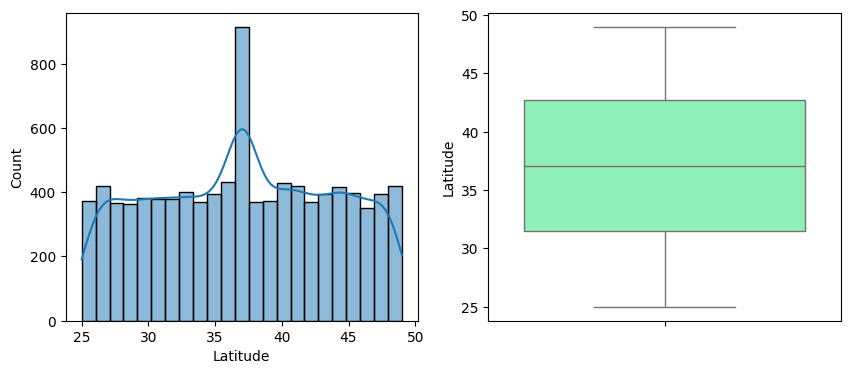

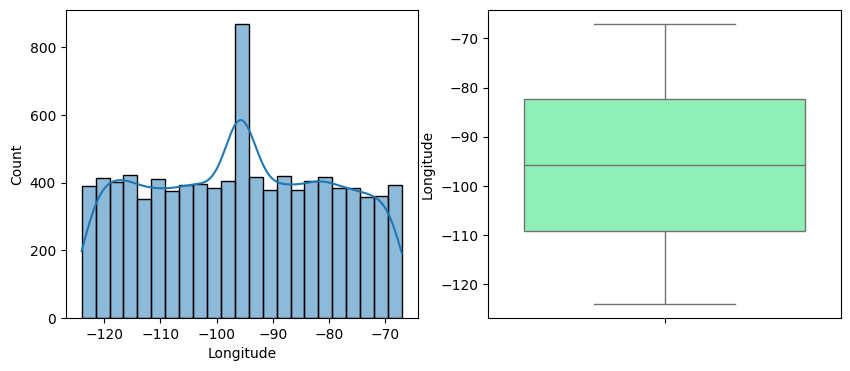

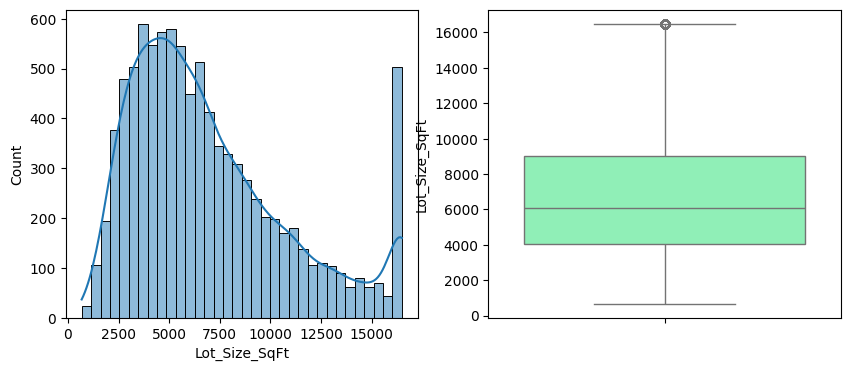

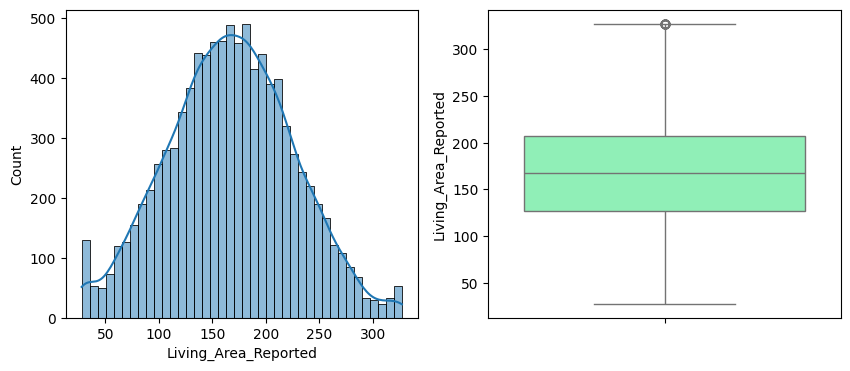

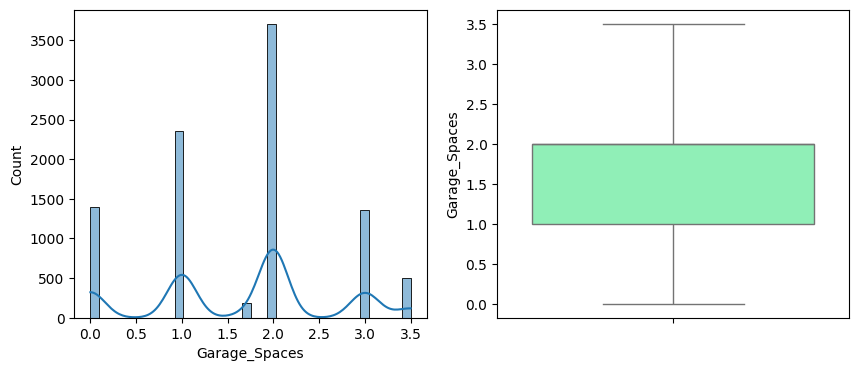

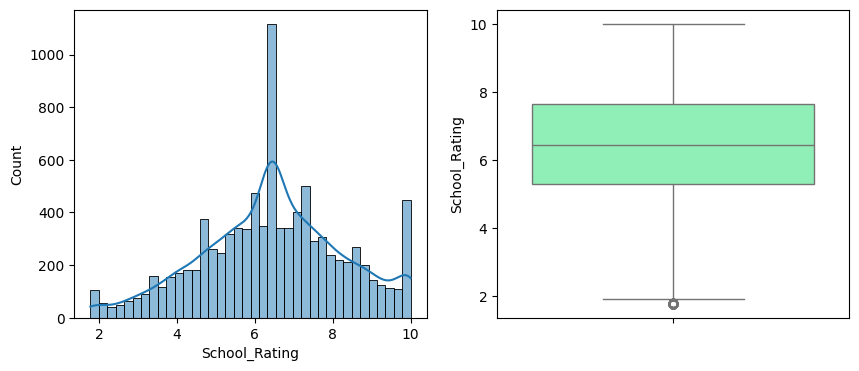

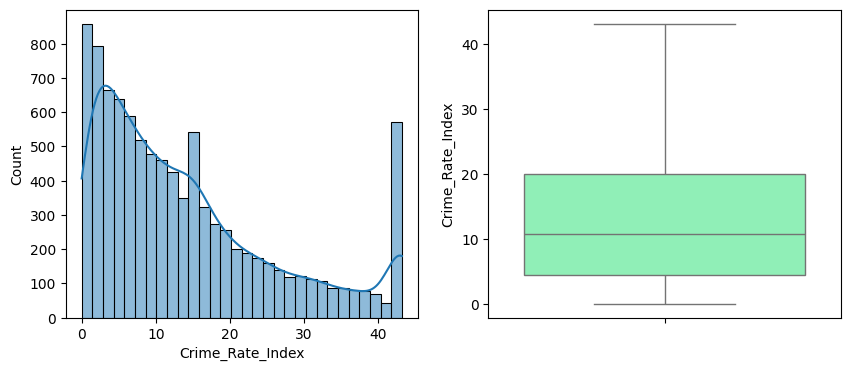

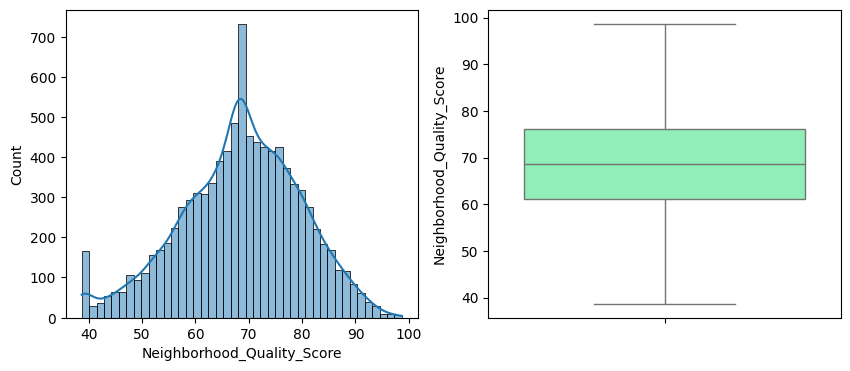

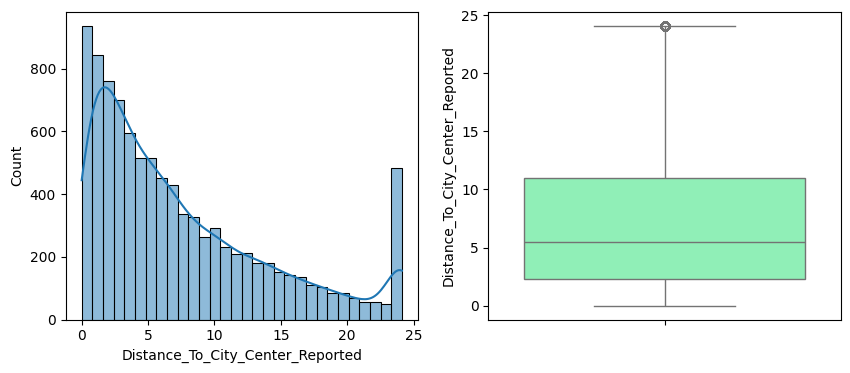

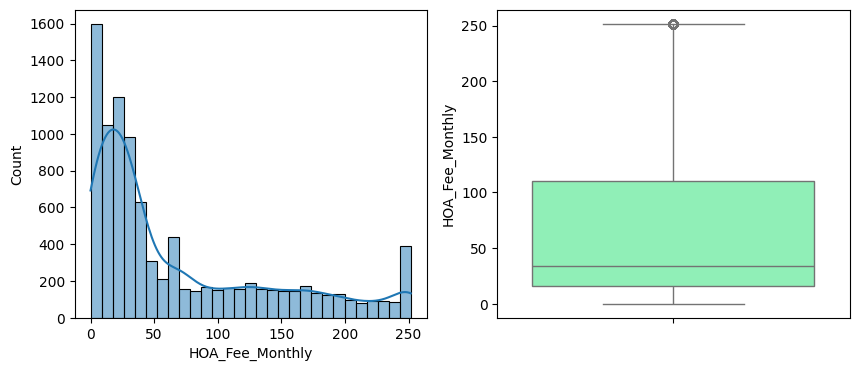

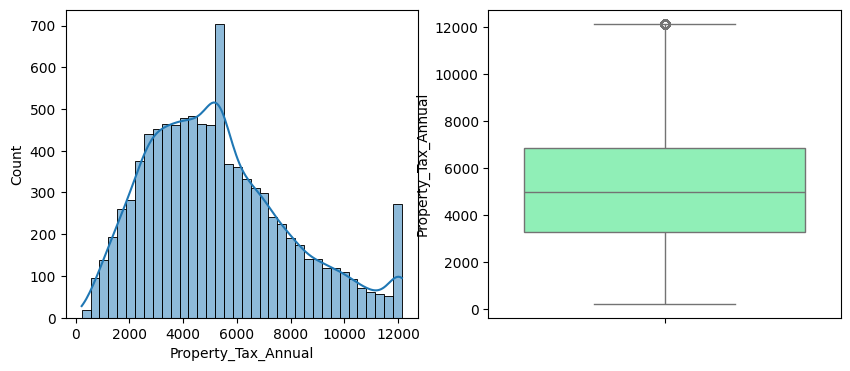

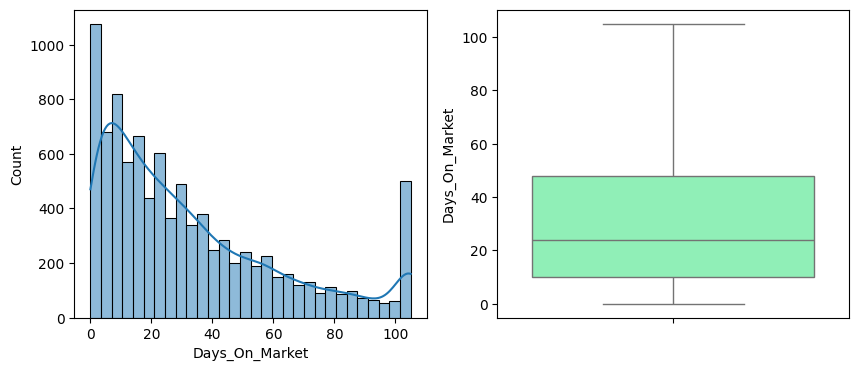

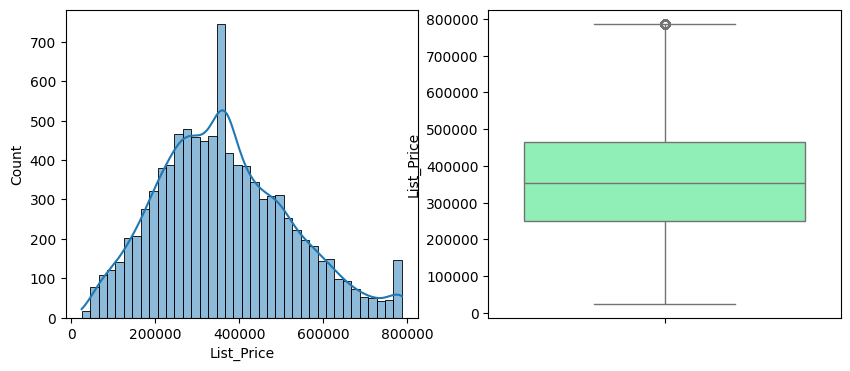

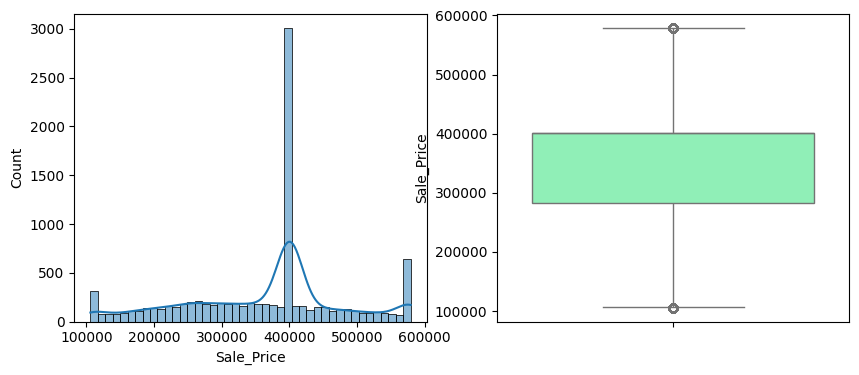

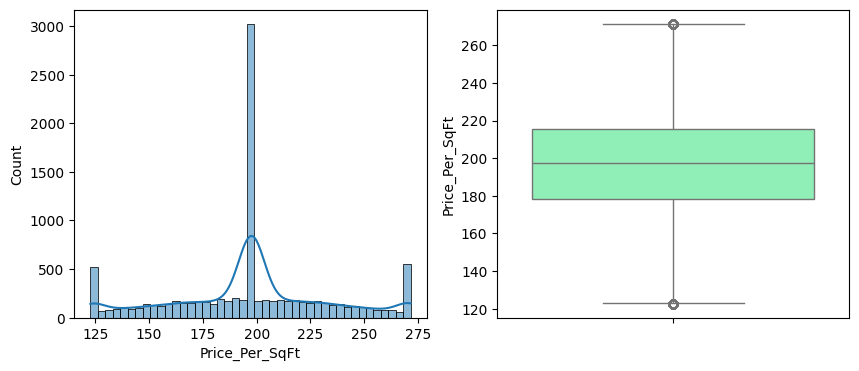

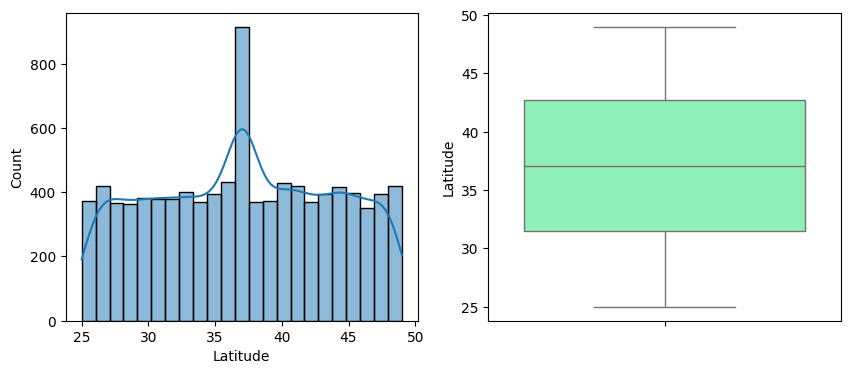

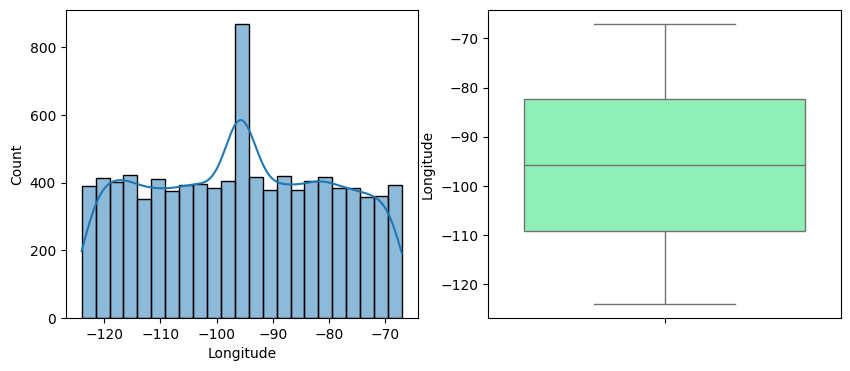

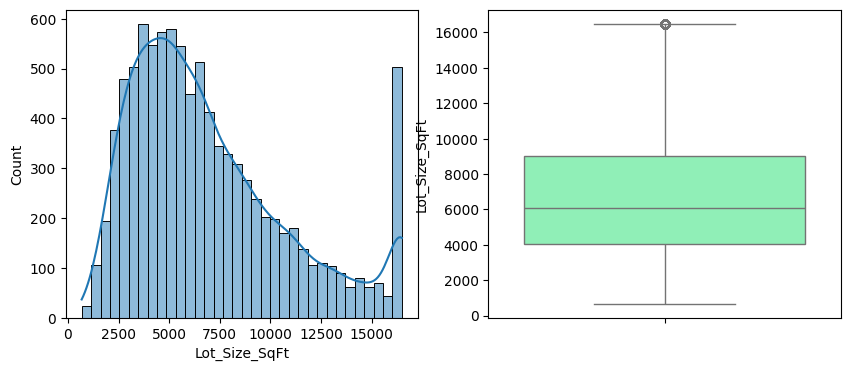

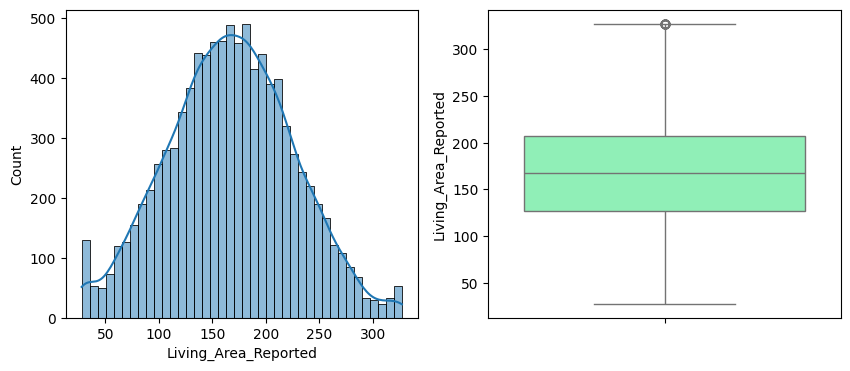

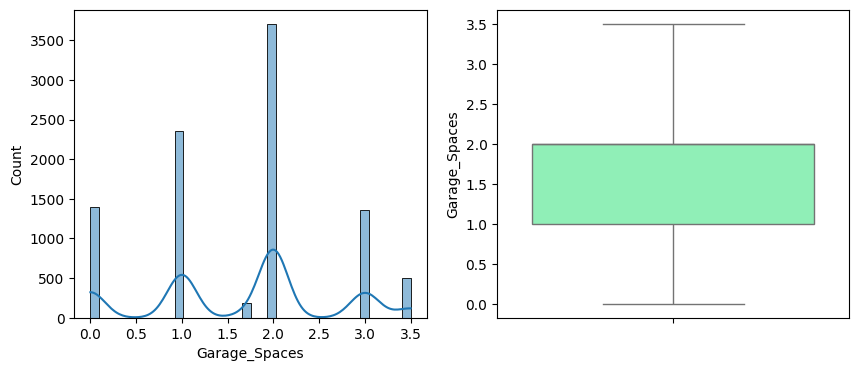

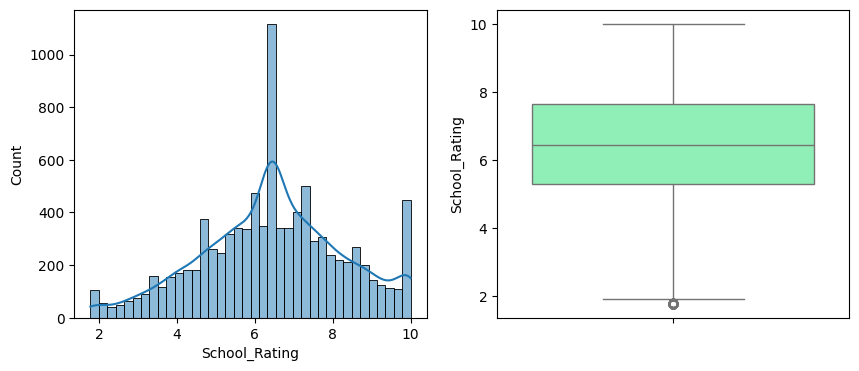

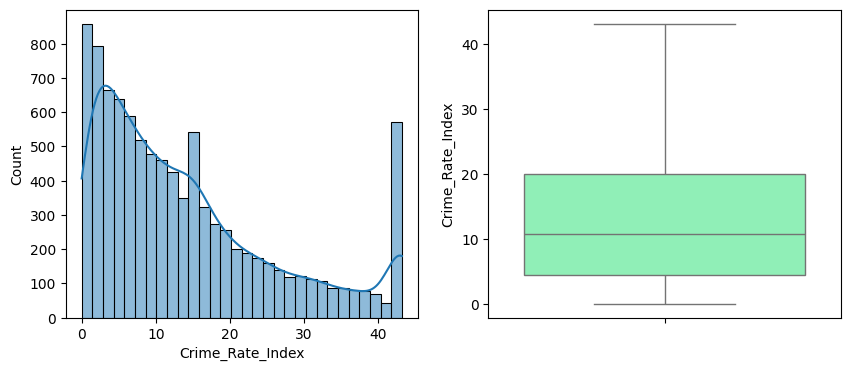

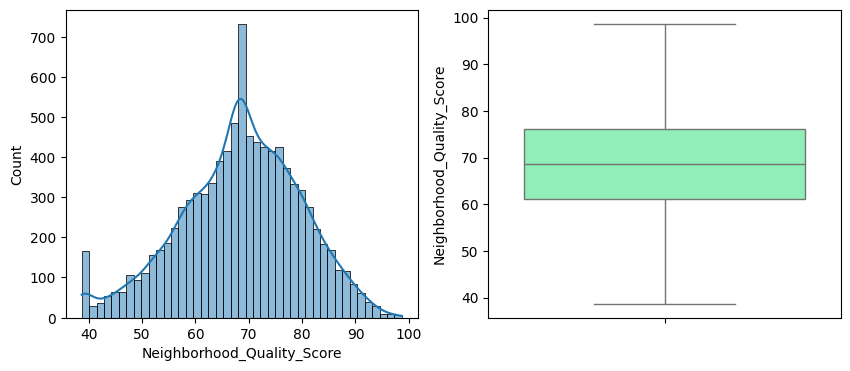

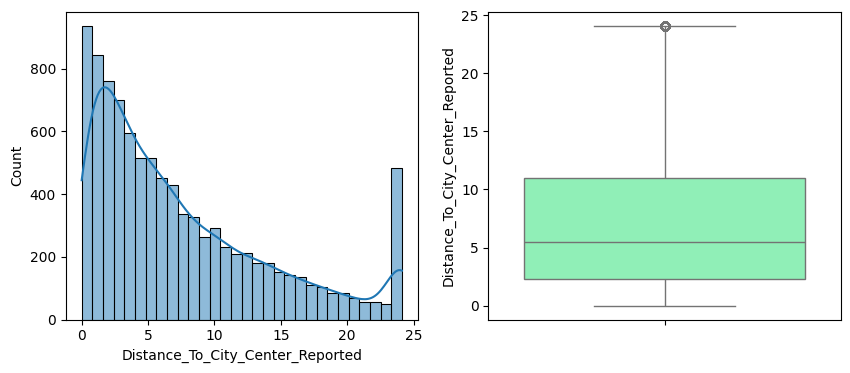

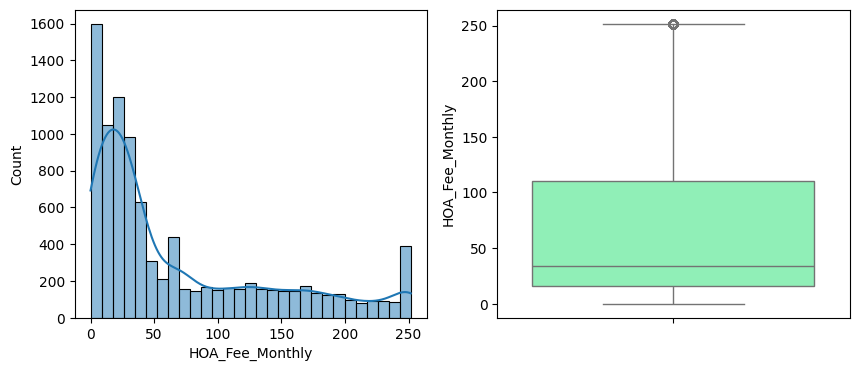

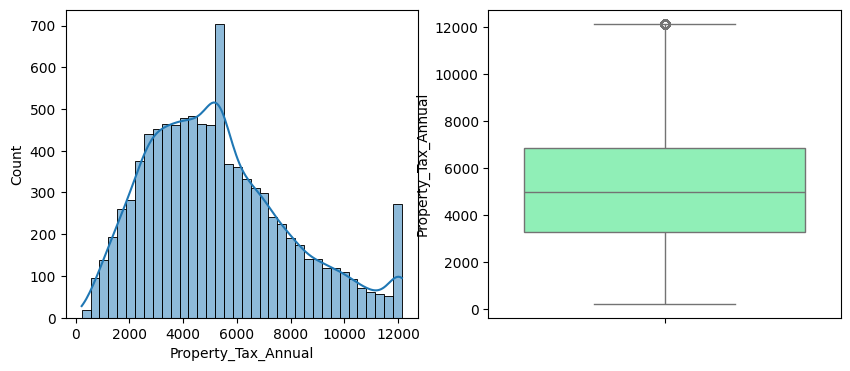

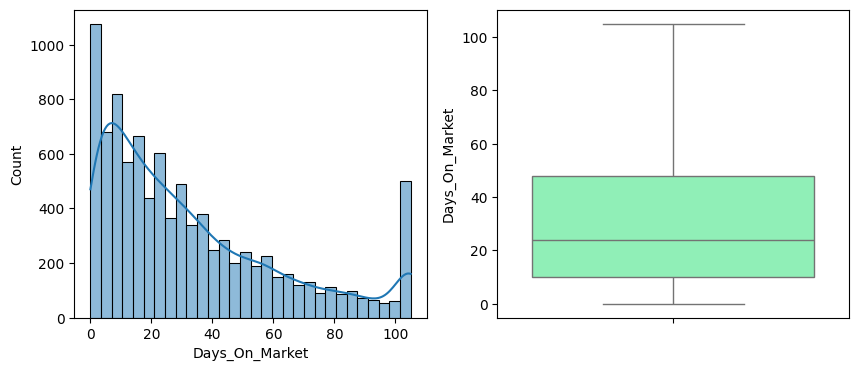

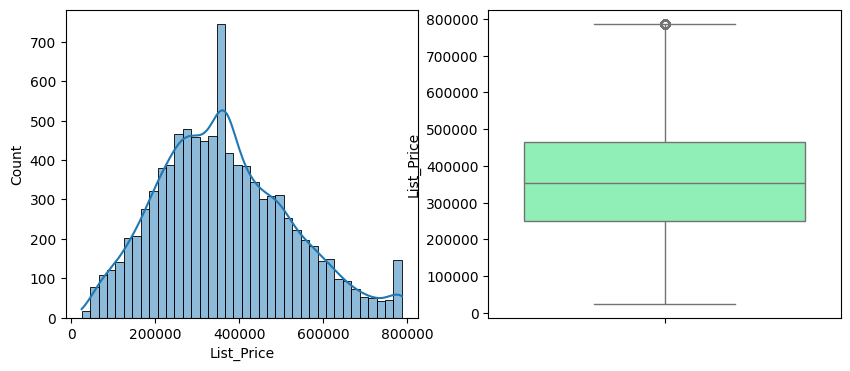

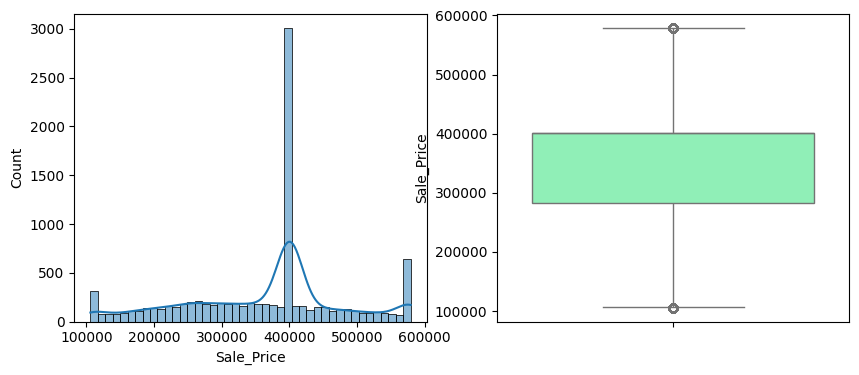

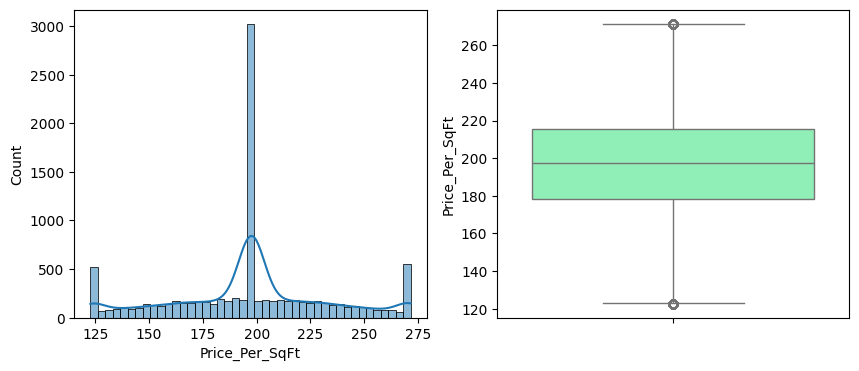

In [144]:
colms_to_chk_outliers=['Latitude','Longitude','Lot_Size_SqFt','Living_Area_Reported','Garage_Spaces',
                       'School_Rating','Crime_Rate_Index','Neighborhood_Quality_Score','Distance_To_City_Center_Reported',
                       'HOA_Fee_Monthly','Property_Tax_Annual','Days_On_Market','List_Price','Sale_Price',
                       'Price_Per_SqFt']


for col in colms_to_chk_outliers:
    plt.figure(figsize=(10, 4))
    plt.subplot(1,2,1)
    plt.title=f"{col}--Histplot"
    sns.histplot(df[col],kde=True,palette='rainbow')
    plt.subplot(1,2,2)
    plt.title=f"{col}--Boxplot"
    sns.boxplot(df[col],palette='rainbow')



    for column in colms_to_chk_outliers:
        Q1 = np.percentile(df[column], 25, method = 'midpoint')
        Q3 = np.percentile(df[column], 75, method = 'midpoint')
        # Step 4: Calculate the IQR
        IQR = Q3 - Q1
        # Step 5: Calculate the lower and upper bound
        lower_bound = Q1 - (1.5 * IQR)
        upper_bound = Q3 + (1.5 * IQR)
        df[column] = df[column].clip(lower=lower_bound, upper=upper_bound)

    
for col in colms_to_chk_outliers:
    plt.figure(figsize=(10, 4))
    plt.subplot(1,2,1)
    plt.title=f"{col}--Histplot"
    sns.histplot(df[col],kde=True,palette='rainbow')
    plt.subplot(1,2,2)
    plt.title=f"{col}--Boxplot"
    sns.boxplot(df[col],palette='rainbow')


,Listing_Date,Sale_Date,Street_Address,City,State,Zip_Code,Latitude,Longitude,Property_Type,Bedrooms,Bathrooms,Lot_Size_SqFt,Living_Area_Reported,Garage_Spaces,Has_Pool,Has_Garden,Heating_Type,Cooling_Type,School_Rating,Crime_Rate_Index,Neighborhood_Quality_Score,Distance_To_City_Center_Reported,HOA_Fee_Monthly,Property_Tax_Annual,Days_On_Market,List_Price,Sale_Price,Price_Per_SqFt,Is_Foreclosure,listing_Year,listing_Month,listing_Day,Sale_Year,Sale_Month,Sale_Day
0,2023-09-25,2025-06-15,43979 Sarah Garden,SEATTLE,Washington,65866.0,41.497476,-107.137238,HOUSE,1,1.0,24440.9,144.176166,2.0,0,1,Gas,Window Unit,6.5,9.77,73.6,19.440000,4.73,5323.18,41,274163.50,400499.371311,197.605121,1,2023,9,25,2025,6,15
1,2024-12-26,2025-09-07,479 Richard Trail Apt. 514,MIAMI,Florida,81824.0,37.096615,-103.096414,TOWNHOUSE,2,1.4,6985.1,171.600000,2.0,0,1,Gas,Window Unit,6.8,1.28,68.5,3.090000,227.44,2787.67,13,324101.48,312852.880000,169.380000,0,2024,12,26,2025,9,7
2,2024-08-15,2025-06-15,6154 Greene Fords Apt. 039,SACRAMENTO,California,80513.0,41.189485,-98.803355,HOUSE,5,4.8,3697.6,62.551590,2.0,0,0,Gas,Window Unit,6.2,3.39,65.6,5.300000,41.60,1424.95,0,98797.61,98767.290000,146.690000,0,2024,8,15,2025,6,15
3,2025-08-21,2026-05-12,8312 Renee Junctions,SACRAMENTO,California,28454.0,48.544489,-67.636640,CONDOMINIUM,2,1.0,2436.3,86.501983,0.0,0,1,Gas,Window Unit,8.4,8.19,81.5,40.828956,169.99,1336.76,1,162391.10,163367.070000,175.460000,0,2025,8,21,2026,5,12
4,2025-05-09,2025-12-13,448 Kim Coves,CHICAGO,Illinois,90058.0,27.647554,-108.595580,TOWNHOUSE,5,4.6,7285.7,225.652097,2.0,1,1,Gas,Window Unit,10.0,4.82,84.8,9.050000,111.16,5077.33,9,489647.12,479931.120000,197.590000,0,2025,5,9,2025,12,13


In [64]:
Q1=np.percentile(df['Sale_Price'],25,method='midpoint')
Q3=np.percentile(df['Sale_Price'],75,method='midpoint')

IQR=Q3-Q1

lower_bound= Q1-(1.5*IQR)
upper_bound= Q3+(1.5*IQR)

outliers=df[(df['Sale_Price']<lower_bound) | (df['Sale_Price']>upper_bound)]
outliers

,Listing_Date,Sale_Date,Street_Address,City,State,Zip_Code,Latitude,Longitude,Property_Type,Bedrooms,Bathrooms,Lot_Size_SqFt,Living_Area_Reported,Garage_Spaces,Has_Pool,Has_Garden,Heating_Type,Cooling_Type,School_Rating,Crime_Rate_Index,Neighborhood_Quality_Score,Distance_To_City_Center_Reported,HOA_Fee_Monthly,Property_Tax_Annual,Days_On_Market,List_Price,Sale_Price,Price_Per_SqFt,Is_Foreclosure,listing_Year,listing_Month,listing_Day,Sale_Year,Sale_Month,Sale_Day
2,2024-08-15,2025-06-15,6154 Greene Fords Apt. 039,SACRAMENTO,California,80513.0,41.189485,-98.803355,HOUSE,5,4.8,3697.6,62.551590,2.0,0,0,Gas,Window Unit,6.2,3.390000,65.6,5.300000,41.60,1424.95,0,98797.61,98767.29,146.69,0,2024,8,15,2025,6,15
12,2023-11-17,2026-08-01,13113 Mason Cliff,COLUMBUS,Ohio,30992.0,38.795476,-77.549176,TOWNHOUSE,2,2.0,8998.3,263.287102,2.0,0,1,Gas,Window Unit,10.0,46.670000,78.9,7.860000,194.75,14030.90,12,653824.77,655040.78,231.14,0,2023,11,17,2026,8,1
35,2025-04-18,2025-04-25,378 Jose Meadow,ATLANTA,Georgia,0.0,38.258324,-105.870031,APARTMENT,1,1.0,13414.3,225.011066,2.0,0,1,Electric,Ductless,7.7,7.750000,80.0,2.253076,157.16,6358.54,149,640456.11,627501.91,259.08,0,2025,4,18,2025,4,25
49,2024-04-10,2024-12-03,8640 Mark Square,COLUMBUS,Ohio,97248.0,46.666295,-80.046626,TOWNHOUSE,6,5.3,5456.1,79.100000,2.0,0,1,Gas,Window Unit,4.5,8.430000,70.5,1.995582,151.71,1772.19,16,97363.35,88672.01,104.15,1,2024,4,10,2024,12,3
50,2025-07-21,2025-07-23,762 Smith Meadow,PHOENIX,Arizona,89942.0,25.011509,-110.541093,TOWNHOUSE,3,3.8,5208.1,34.485594,4.0,0,1,Solar,Window Unit,4.3,2.900000,57.7,36.017029,0.00,910.69,25,104747.66,95133.30,256.29,0,2025,7,21,2025,7,23
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9463,2025-11-04,2026-02-22,467 Judy Haven Suite 143,DALLAS,Texas,0.0,29.925222,-68.076957,HOUSE,5,3.4,6368.5,27.900000,1.0,0,1,Gas,Window Unit,6.5,12.900000,65.3,5.000000,41.88,685.79,85,87438.56,80761.91,269.21,0,2025,11,4,2026,2,22
9466,2025-10-04,2025-11-01,158 Allison Meadow Apt. 393,COLUMBUS,Ohio,40492.0,41.155202,-107.707371,HOUSE,4,4.2,8143.7,183.659941,2.0,0,0,Geothermal,Window Unit,9.6,6.910000,75.7,0.460000,11.59,11882.47,90,609094.97,618207.08,312.72,0,2025,10,4,2025,11,1
9470,2026-06-30,2026-07-02,312 Dickerson Stream,SEATTLE,Washington,70682.0,44.346855,-123.144863,TOWNHOUSE,3,2.0,7843.0,314.700000,1.0,0,0,Oil,Window Unit,8.0,8.390000,78.8,0.434522,168.45,12882.19,21,671907.07,682323.99,201.41,0,2026,6,30,2026,7,2
9473,2026-03-18,2026-04-07,9043 Anderson Burgs,NASHVILLE,Tennessee,26483.0,35.113007,-102.354988,TOWNHOUSE,2,1.2,6447.3,46.832402,0.0,0,1,Solar,Window Unit,7.2,14.836174,58.6,15.658878,124.22,1841.89,20,84469.16,96504.03,191.44,0,2026,3,18,2026,4,7


In [145]:
df['Sale_Price'].skew()

np.float64(-0.2675590360463208)

In [71]:
less=np.log1p(df['Sale_Price'])
less.skew()

np.float64(-0.030362507998046646)

In [83]:
from sklearn.preprocessing import QuantileTransformer

qt=QuantileTransformer(output_distribution='normal',random_state=42)

less2=qt.fit_transform(df[['Sale_Price']])
less2=pd.DataFrame(less2,columns=['Sale'])
# sns.histplot(less2,kde=True)
less2.skew()


Sale   -0.006599
dtype: float64

In [91]:
for col in colms_to_chk_outliers:
    print(f"{col}----->",df[col].skew())

Latitude-----> -0.018965833431458072
Longitude-----> 0.007990255834565727
Lot_Size_SqFt-----> -0.0036468753923709096
Living_Area_Reported-----> 0.059997829880519736
Garage_Spaces-----> 0.13517121002759722
School_Rating-----> -0.17565586846518122
Crime_Rate_Index-----> -0.021686630422596512
Neighborhood_Quality_Score-----> -0.5088204471635709
Distance_To_City_Center_Reported-----> -0.053428076746827056
HOA_Fee_Monthly-----> -1.7531926461946021
Property_Tax_Annual-----> 0.0027258673314206343
Days_On_Market-----> -1.5886259463885877
List_Price-----> -0.0009127383606441679
Sale_Price-----> 22.12187717406979
Price_Per_SqFt-----> 0.13172445127039317


In [146]:
df.to_csv("outliers_removed9.csv",index=False)

In [133]:
df=pd.read_csv("D:\Python and projects\summer\House Price Pred\Before_transformation8.csv")

In [134]:
df.head()

,Listing_Date,Sale_Date,Street_Address,Zip_Code,Latitude,Longitude,Bedrooms,Bathrooms,Lot_Size_SqFt,Living_Area_Reported,Garage_Spaces,Has_Pool,Has_Garden,School_Rating,Crime_Rate_Index,Neighborhood_Quality_Score,Distance_To_City_Center_Reported,HOA_Fee_Monthly,Property_Tax_Annual,Days_On_Market,List_Price,Sale_Price,Price_Per_SqFt,Is_Foreclosure,listing_Year,listing_Month,listing_Day,Sale_Year,Sale_Month,Sale_Day,City_AUSTIN,City_BOSTON,City_CHARLOTTE,City_CHICAGO,City_COLUMBUS,City_DALLAS,City_DENVER,City_MIAMI,City_NASHVILLE,City_ORLANDO,City_PHOENIX,City_PORTLAND,City_RALEIGH,City_SACRAMENTO,City_SEATTLE,State_California,State_Colorado,State_Florida,State_Georgia,State_Illinois,State_Massachusetts,State_North Carolina,State_Ohio,State_Oregon,State_Tennessee,State_Texas,State_Washington,Property_Type_CONDOMINIUM,Property_Type_DUPLEX,Property_Type_HOUSE,Property_Type_TOWNHOUSE,Property_Type_VILLA,Heating_Type_Electric,Heating_Type_Gas,Heating_Type_Geothermal,Heating_Type_Oil,Heating_Type_Solar,Heating_Type_Wood,Cooling_Type_Ductless,Cooling_Type_Evaporative,Cooling_Type_Window Unit
0,2023-09-25,2025-06-15,43979 Sarah Garden,65866.0,41.497476,-107.137238,1,1.0,24440.9,144.176166,2.0,0,1,6.5,9.77,73.6,19.440000,4.73,5323.18,41,274163.50,400499.371311,197.605121,1,2023,9,25,2025,6,15,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,1,0,0,0,0,0,0,1
1,2024-12-26,2025-09-07,479 Richard Trail Apt. 514,81824.0,37.096615,-103.096414,2,1.4,6985.1,171.600000,2.0,0,1,6.8,1.28,68.5,3.090000,227.44,2787.67,13,324101.48,312852.880000,169.380000,0,2024,12,26,2025,9,7,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,1
2,2024-08-15,2025-06-15,6154 Greene Fords Apt. 039,80513.0,41.189485,-98.803355,5,4.8,3697.6,62.551590,2.0,0,0,6.2,3.39,65.6,5.300000,41.60,1424.95,0,98797.61,98767.290000,146.690000,0,2024,8,15,2025,6,15,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1
3,2025-08-21,2026-05-12,8312 Renee Junctions,28454.0,48.544489,-67.636640,2,1.0,2436.3,86.501983,0.0,0,1,8.4,8.19,81.5,40.828956,169.99,1336.76,1,162391.10,163367.070000,175.460000,0,2025,8,21,2026,5,12,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,1
4,2025-05-09,2025-12-13,448 Kim Coves,90058.0,27.647554,-108.595580,5,4.6,7285.7,225.652097,2.0,1,1,10.0,4.82,84.8,9.050000,111.16,5077.33,9,489647.12,479931.120000,197.590000,0,2025,5,9,2025,12,13,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,1


In [ ]:
for col in colms_to_chk_outliers:
    plt.figure(figsize=(10, 4))
    plt.subplot(1,2,1)
    plt.title=f"{col}--Histplot"
    sns.histplot(df[col],kde=True,palette='rainbow')
    plt.subplot(1,2,2)
    plt.title=f"{col}--Boxplot"
    sns.boxplot(df[col],palette='rainbow')

In [136]:
df.head()

,Listing_Date,Sale_Date,Street_Address,Zip_Code,Latitude,Longitude,Bedrooms,Bathrooms,Lot_Size_SqFt,Living_Area_Reported,Garage_Spaces,Has_Pool,Has_Garden,School_Rating,Crime_Rate_Index,Neighborhood_Quality_Score,Distance_To_City_Center_Reported,HOA_Fee_Monthly,Property_Tax_Annual,Days_On_Market,List_Price,Sale_Price,Price_Per_SqFt,Is_Foreclosure,listing_Year,listing_Month,listing_Day,Sale_Year,Sale_Month,Sale_Day,City_AUSTIN,City_BOSTON,City_CHARLOTTE,City_CHICAGO,City_COLUMBUS,City_DALLAS,City_DENVER,City_MIAMI,City_NASHVILLE,City_ORLANDO,City_PHOENIX,City_PORTLAND,City_RALEIGH,City_SACRAMENTO,City_SEATTLE,State_California,State_Colorado,State_Florida,State_Georgia,State_Illinois,State_Massachusetts,State_North Carolina,State_Ohio,State_Oregon,State_Tennessee,State_Texas,State_Washington,Property_Type_CONDOMINIUM,Property_Type_DUPLEX,Property_Type_HOUSE,Property_Type_TOWNHOUSE,Property_Type_VILLA,Heating_Type_Electric,Heating_Type_Gas,Heating_Type_Geothermal,Heating_Type_Oil,Heating_Type_Solar,Heating_Type_Wood,Cooling_Type_Ductless,Cooling_Type_Evaporative,Cooling_Type_Window Unit
0,2023-09-25,2025-06-15,43979 Sarah Garden,65866.0,41.497476,-107.137238,1,1.0,24440.9,144.176166,2.0,0,1,6.5,9.77,73.6,19.440000,4.73,5323.18,41,274163.50,400499.371311,197.605121,1,2023,9,25,2025,6,15,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,1,0,0,0,0,0,0,1
1,2024-12-26,2025-09-07,479 Richard Trail Apt. 514,81824.0,37.096615,-103.096414,2,1.4,6985.1,171.600000,2.0,0,1,6.8,1.28,68.5,3.090000,227.44,2787.67,13,324101.48,312852.880000,169.380000,0,2024,12,26,2025,9,7,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,1
2,2024-08-15,2025-06-15,6154 Greene Fords Apt. 039,80513.0,41.189485,-98.803355,5,4.8,3697.6,62.551590,2.0,0,0,6.2,3.39,65.6,5.300000,41.60,1424.95,0,98797.61,98767.290000,146.690000,0,2024,8,15,2025,6,15,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1
3,2025-08-21,2026-05-12,8312 Renee Junctions,28454.0,48.544489,-67.636640,2,1.0,2436.3,86.501983,0.0,0,1,8.4,8.19,81.5,40.828956,169.99,1336.76,1,162391.10,163367.070000,175.460000,0,2025,8,21,2026,5,12,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,1
4,2025-05-09,2025-12-13,448 Kim Coves,90058.0,27.647554,-108.595580,5,4.6,7285.7,225.652097,2.0,1,1,10.0,4.82,84.8,9.050000,111.16,5077.33,9,489647.12,479931.120000,197.590000,0,2025,5,9,2025,12,13,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,1


In [150]:
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split


x=df.drop(columns=['Sale_Price','Listing_Date','Sale_Date','Street_Address'])
y=df['Sale_Price']


X_train,X_test,Y_train,Y_test=train_test_split(x,y,test_size=0.2,random_state=42)


cols_to_transform = [
    'List_Price',                      # Optional
    'HOA_Fee_Monthly',                 # Consider
    'Property_Tax_Annual',             # Consider
    'Lot_Size_SqFt',                   # Definitely
    'Crime_Rate_Index',                # Definitely
    'Distance_To_City_Center_Reported',# Definitely
    'Days_On_Market'                   # Definitely
]


qt=QuantileTransformer(output_distribution='normal',random_state=42)
X_train[cols_to_transform]=qt.fit_transform(X_train[cols_to_transform])
X_test[cols_to_transform]=qt.transform(X_test[cols_to_transform])


In [152]:
columns_left_transform = [
    'Latitude',
    'Longitude',
    'Living_Area_Reported',
    'Garage_Spaces',
    'School_Rating',
    'Price_Per_SqFt',
    'Zip_Code',
    'listing_Year',
    'listing_Month',
    'listing_Day',
    'Sale_Year',
    'Sale_Month',
    'Sale_Day',
    'Neighborhood_Quality_Score'
]
rs=RobustScaler()
X_train[columns_left_transform]=rs.fit_transform(X_train[columns_left_transform])

X_test[columns_left_transform]=rs.transform(X_test[columns_left_transform])


In [153]:
from sklearn.linear_model import LinearRegression,Lasso,Ridge,SGDRegressor
X_train,X_test,Y_train,Y_test=train_test_split(x,y,test_size=0.2,random_state=42)

from sklearn.metrics import r2_score

model=LinearRegression()
model.fit(X_train,Y_train)

y_pred=model.predict(X_test)

print(r2_score(y_true=Y_test,y_pred=y_pred))




0.7019733750002112


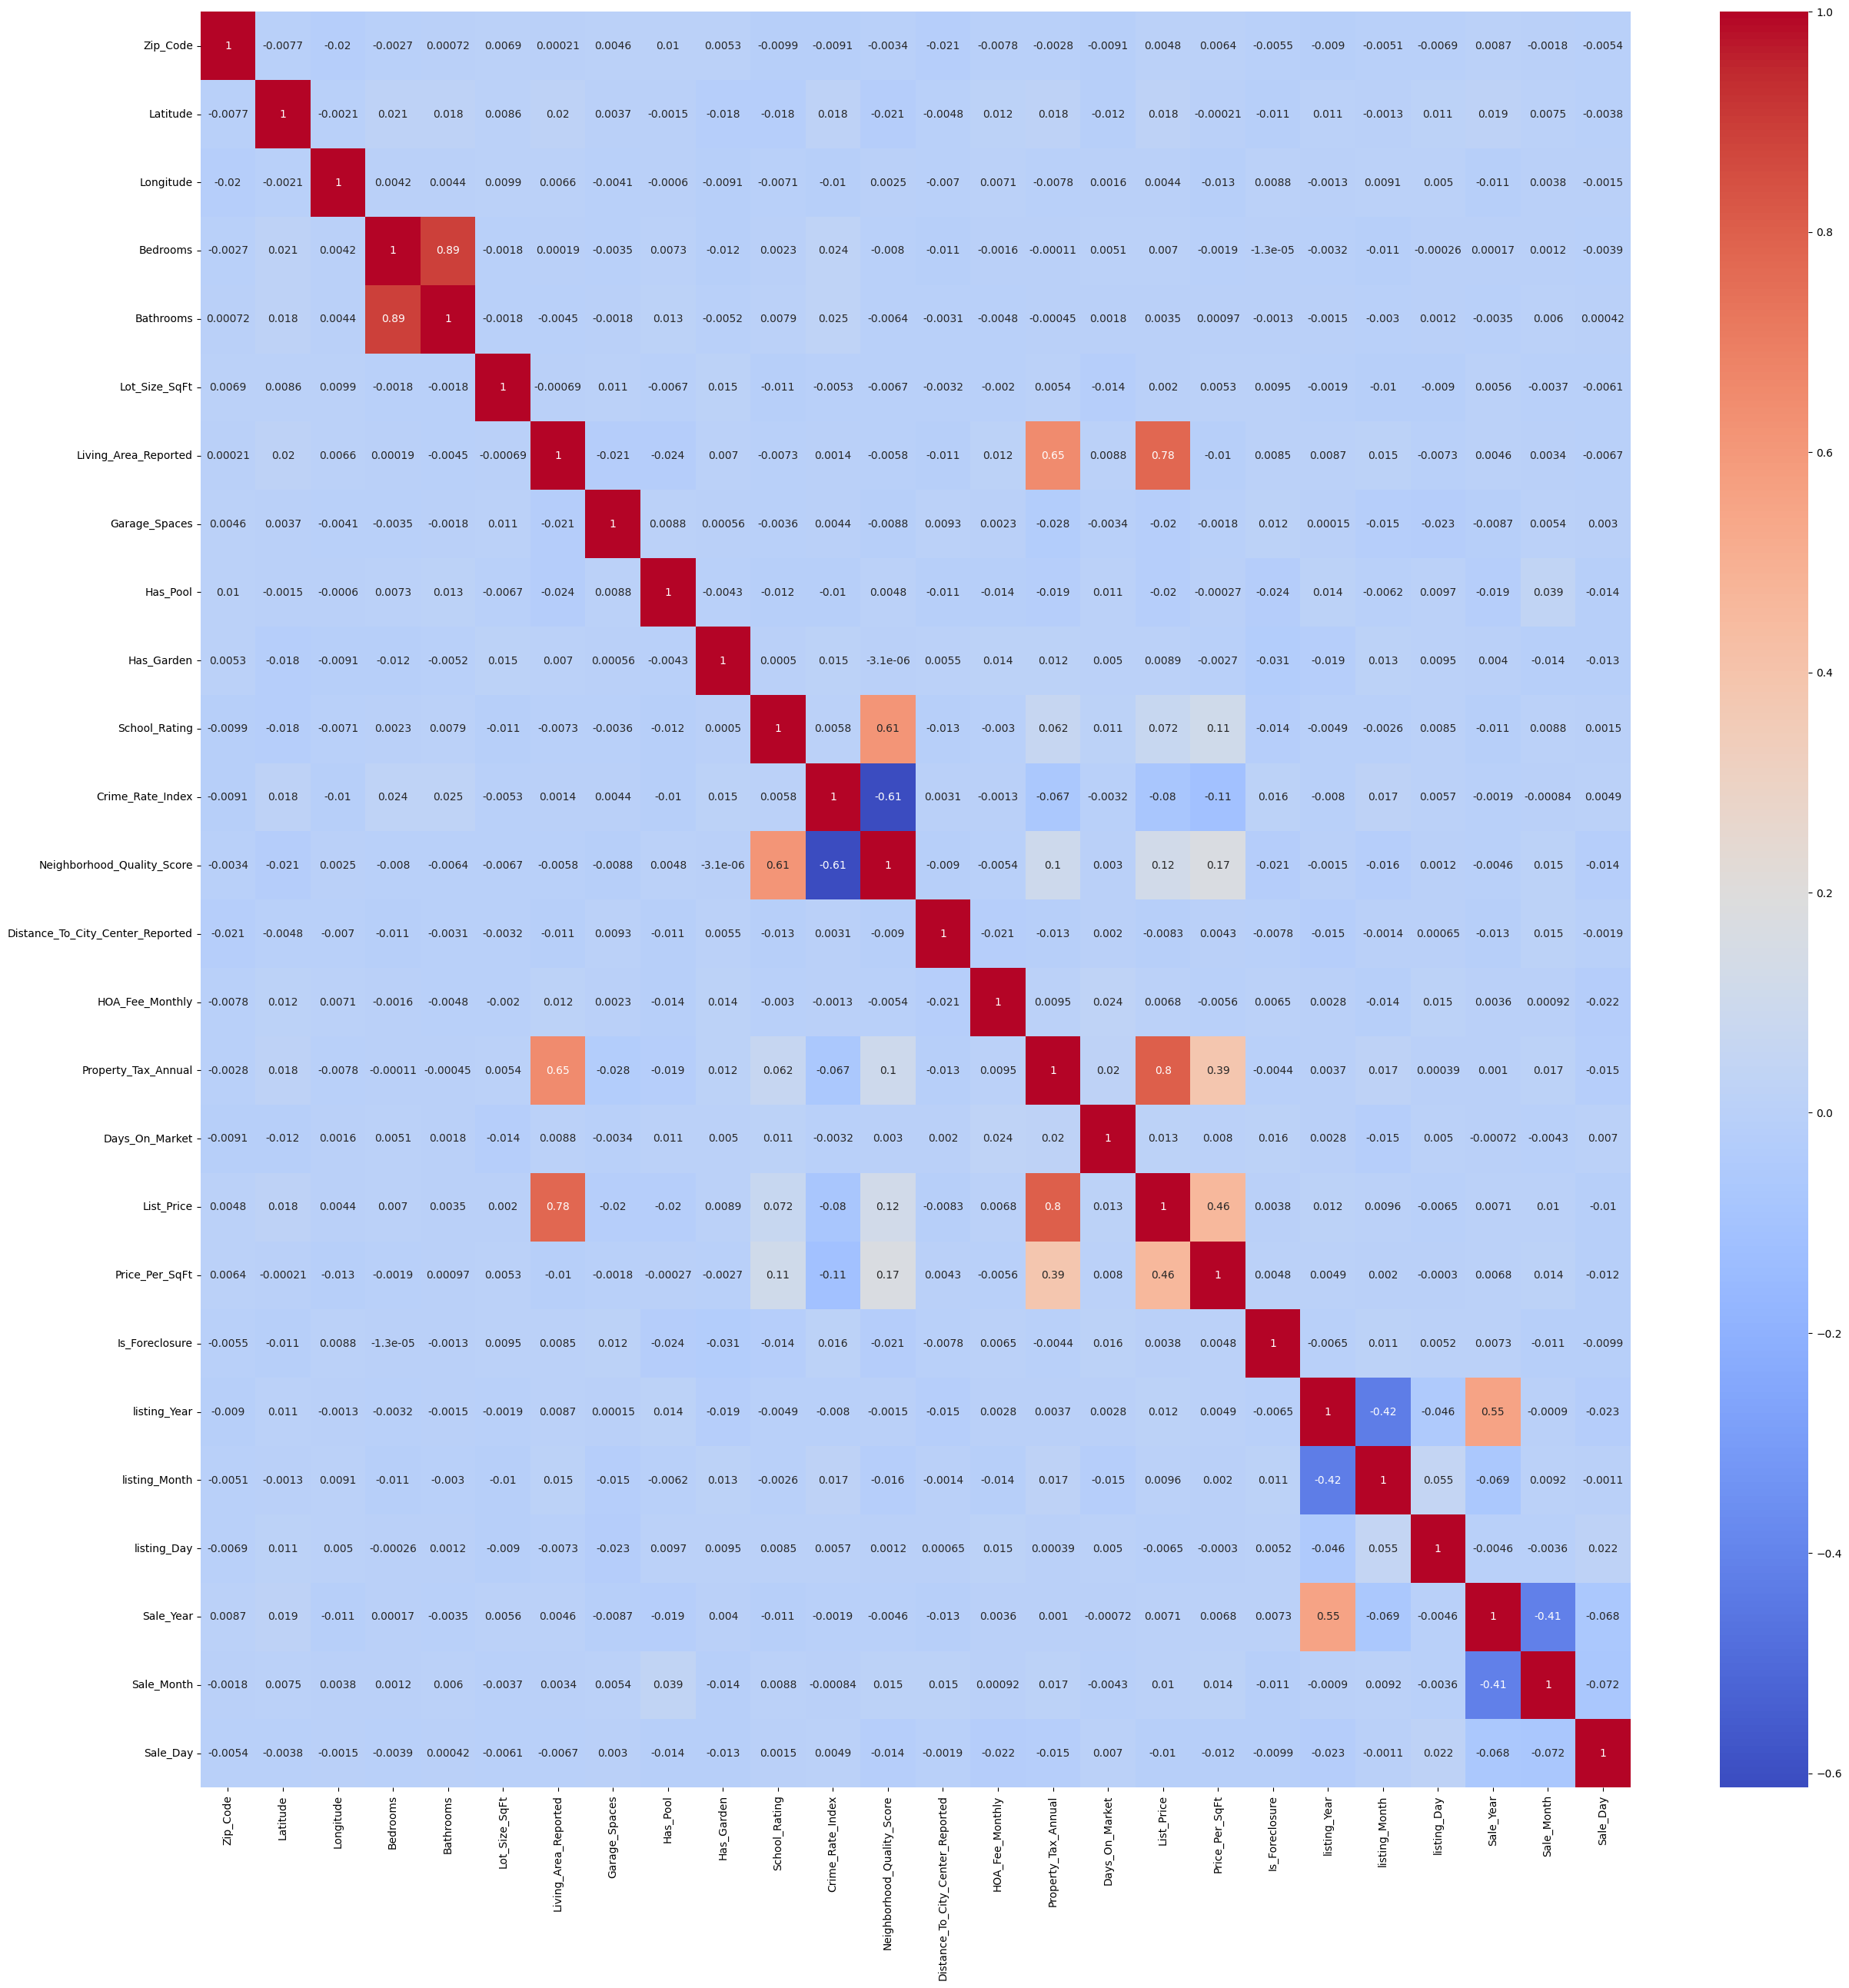

In [107]:
plt.figure(figsize=(30, 30))

corr = x.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap='coolwarm')

plt.show()

In [108]:
df.corr(numeric_only=True)

,Zip_Code,Latitude,Longitude,Bedrooms,Bathrooms,Lot_Size_SqFt,Living_Area_Reported,Garage_Spaces,Has_Pool,Has_Garden,School_Rating,Crime_Rate_Index,Neighborhood_Quality_Score,Distance_To_City_Center_Reported,HOA_Fee_Monthly,Property_Tax_Annual,Days_On_Market,List_Price,Sale_Price,Price_Per_SqFt,Is_Foreclosure,listing_Year,listing_Month,listing_Day,Sale_Year,Sale_Month,Sale_Day
Zip_Code,1.000000,-0.007702,-0.019542,-0.002664,0.000720,0.006885,0.000207,0.004564,0.010069,0.005283,-0.009866,-0.009143,-0.003443,-0.020616,-0.007785,-0.002782,-0.009129,0.004841,-0.012969,0.006372,-0.005528,-0.009003,-0.005054,-0.006876,0.008659,-0.001761,-0.005423
Latitude,-0.007702,1.000000,-0.002120,0.020713,0.018182,0.008560,0.020467,0.003690,-0.001475,-0.018351,-0.018179,0.017720,-0.021145,-0.004782,0.012197,0.018117,-0.012289,0.017944,0.015719,-0.000206,-0.010637,0.010758,-0.001271,0.011467,0.019008,0.007527,-0.003832
Longitude,-0.019542,-0.002120,1.000000,0.004206,0.004429,0.009872,0.006563,-0.004084,-0.000602,-0.009133,-0.007146,-0.010300,0.002528,-0.007023,0.007129,-0.007799,0.001577,0.004449,-0.010450,-0.012644,0.008830,-0.001306,0.009104,0.005023,-0.010536,0.003770,-0.001472
Bedrooms,-0.002664,0.020713,0.004206,1.000000,0.889661,-0.001828,0.000191,-0.003549,0.007287,-0.011553,0.002318,0.023801,-0.007962,-0.010593,-0.001579,-0.000111,0.005136,0.006995,0.004354,-0.001851,-0.000013,-0.003205,-0.010710,-0.000258,0.000170,0.001246,-0.003854
Bathrooms,0.000720,0.018182,0.004429,0.889661,1.000000,-0.001817,-0.004517,-0.001763,0.013026,-0.005199,0.007931,0.025495,-0.006418,-0.003103,-0.004783,-0.000450,0.001805,0.003494,0.002061,0.000970,-0.001309,-0.001548,-0.003022,0.001208,-0.003521,0.005988,0.000417
Lot_Size_SqFt,0.006885,0.008560,0.009872,-0.001828,-0.001817,1.000000,-0.000686,0.010509,-0.006684,0.014624,-0.011387,-0.005330,-0.006697,-0.003153,-0.002027,0.005384,-0.014472,0.001953,-0.001727,0.005293,0.009498,-0.001879,-0.010034,-0.009010,0.005615,-0.003684,-0.006059
Living_Area_Reported,0.000207,0.020467,0.006563,0.000191,-0.004517,-0.000686,1.000000,-0.021221,-0.023730,0.007038,-0.007292,0.001382,-0.005779,-0.010861,0.011742,0.650092,0.008847,0.775399,0.144210,-0.010292,0.008537,0.008695,0.014510,-0.007305,0.004583,0.003376,-0.006719
Garage_Spaces,0.004564,0.003690,-0.004084,-0.003549,-0.001763,0.010509,-0.021221,1.000000,0.008759,0.000562,-0.003564,0.004443,-0.008750,0.009313,0.002280,-0.028092,-0.003450,-0.019744,-0.002456,-0.001815,0.011629,0.000148,-0.015354,-0.023474,-0.008744,0.005425,0.002964
Has_Pool,0.010069,-0.001475,-0.000602,0.007287,0.013026,-0.006684,-0.023730,0.008759,1.000000,-0.004280,-0.012189,-0.010385,0.004846,-0.011115,-0.014285,-0.018827,0.010652,-0.019660,-0.024778,-0.000269,-0.023908,0.013610,-0.006156,0.009722,-0.018936,0.038601,-0.014095
Has_Garden,0.005283,-0.018351,-0.009133,-0.011553,-0.005199,0.014624,0.007038,0.000562,-0.004280,1.000000,0.000498,0.014768,-0.000003,0.005452,0.013673,0.011586,0.004988,0.008908,-0.010918,-0.002724,-0.030871,-0.019073,0.012992,0.009521,0.003972,-0.014215,-0.013105


In [ ]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline

poly_model = Pipeline([
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('linear', LinearRegression())
])

poly_model.fit(X_train, Y_train)

y_pred = poly_model.predict(X_test)

print(r2_score(Y_test, y_pred))


0.7346053079099681


In [163]:
from sklearn.linear_model import Lasso
from sklearn.metrics import r2_score

lasso = Lasso(alpha=0.1, random_state=42)

lasso.fit(X_train, Y_train)

y_pred = lasso.predict(X_test)

print("R² Score:", r2_score(Y_test, y_pred))

R² Score: 0.7019752705702779


### -------------------- without scaling -------------------------------

In [135]:
df.head()

,Listing_Date,Sale_Date,Street_Address,Zip_Code,Latitude,Longitude,Bedrooms,Bathrooms,Lot_Size_SqFt,Living_Area_Reported,Garage_Spaces,Has_Pool,Has_Garden,School_Rating,Crime_Rate_Index,Neighborhood_Quality_Score,Distance_To_City_Center_Reported,HOA_Fee_Monthly,Property_Tax_Annual,Days_On_Market,List_Price,Sale_Price,Price_Per_SqFt,Is_Foreclosure,listing_Year,listing_Month,listing_Day,Sale_Year,Sale_Month,Sale_Day,City_AUSTIN,City_BOSTON,City_CHARLOTTE,City_CHICAGO,City_COLUMBUS,City_DALLAS,City_DENVER,City_MIAMI,City_NASHVILLE,City_ORLANDO,City_PHOENIX,City_PORTLAND,City_RALEIGH,City_SACRAMENTO,City_SEATTLE,State_California,State_Colorado,State_Florida,State_Georgia,State_Illinois,State_Massachusetts,State_North Carolina,State_Ohio,State_Oregon,State_Tennessee,State_Texas,State_Washington,Property_Type_CONDOMINIUM,Property_Type_DUPLEX,Property_Type_HOUSE,Property_Type_TOWNHOUSE,Property_Type_VILLA,Heating_Type_Electric,Heating_Type_Gas,Heating_Type_Geothermal,Heating_Type_Oil,Heating_Type_Solar,Heating_Type_Wood,Cooling_Type_Ductless,Cooling_Type_Evaporative,Cooling_Type_Window Unit
0,2023-09-25,2025-06-15,43979 Sarah Garden,65866.0,41.497476,-107.137238,1,1.0,24440.9,144.176166,2.0,0,1,6.5,9.77,73.6,19.440000,4.73,5323.18,41,274163.50,400499.371311,197.605121,1,2023,9,25,2025,6,15,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,1,0,0,0,0,0,0,1
1,2024-12-26,2025-09-07,479 Richard Trail Apt. 514,81824.0,37.096615,-103.096414,2,1.4,6985.1,171.600000,2.0,0,1,6.8,1.28,68.5,3.090000,227.44,2787.67,13,324101.48,312852.880000,169.380000,0,2024,12,26,2025,9,7,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,1
2,2024-08-15,2025-06-15,6154 Greene Fords Apt. 039,80513.0,41.189485,-98.803355,5,4.8,3697.6,62.551590,2.0,0,0,6.2,3.39,65.6,5.300000,41.60,1424.95,0,98797.61,98767.290000,146.690000,0,2024,8,15,2025,6,15,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1
3,2025-08-21,2026-05-12,8312 Renee Junctions,28454.0,48.544489,-67.636640,2,1.0,2436.3,86.501983,0.0,0,1,8.4,8.19,81.5,40.828956,169.99,1336.76,1,162391.10,163367.070000,175.460000,0,2025,8,21,2026,5,12,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,1
4,2025-05-09,2025-12-13,448 Kim Coves,90058.0,27.647554,-108.595580,5,4.6,7285.7,225.652097,2.0,1,1,10.0,4.82,84.8,9.050000,111.16,5077.33,9,489647.12,479931.120000,197.590000,0,2025,5,9,2025,12,13,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,1


In [149]:
from sklearn.linear_model import LinearRegression,Lasso,Ridge,SGDRegressor
from sklearn.metrics import r2_score


x=df.drop(columns=['Sale_Price','Listing_Date','Sale_Date','Street_Address'])
y=df['Sale_Price']


model=LinearRegression()
model.fit(X_train,Y_train)

y_pred=model.predict(X_test)

print(r2_score(y_true=Y_test,y_pred=y_pred))



lasso = Lasso(alpha=0.01, random_state=42)

lasso.fit(X_train, Y_train)

y_pred = lasso.predict(X_test)

print("R² Score:", r2_score(Y_test, y_pred))


0.03672264511504297
R² Score: 0.03672269017346075


In [164]:
df.shape

(9500, 71)

## Saving polynomial Model

In [165]:
import joblib

joblib.dump(poly_model,"House_price_model.pkl")

['House_price_model.pkl']